<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 9 : Naive Bayes

1. Why Naive Bayes?
2. Bayes' Theorem
3. Conditional Probability
4. Prior Probability
5. Posterior Probability
6. Likelihood
7. Independence Assumption
8. Gaussian Naive Bayes
9. Multinomial Naive Bayes
10. Bernoulli Naive Bayes
11. Laplace Smoothing
12. Log Probability
13. Hyperparameters
14. Python to compare and show all of the above (dataset : Spam Detection)
15. Comparison with Logistic Regression
16. Questions

## 1. Why Naive Bayes?


### 1.1 Why we need Naive Bayes

Naive Bayes is a powerful and widely used classification algorithm, particularly effective in scenarios involving large datasets and text classification tasks. We need Naive Bayes for several key reasons:

*   **Simplicity and Speed:** It's a very straightforward algorithm based on Bayes' theorem with strong independence assumptions. This simplicity translates to fast training and prediction times, making it ideal for real-time applications or systems with limited computational resources.

*   **Good Performance on Text Data:** Naive Bayes classifiers are renowned for their effectiveness in text classification problems, such as spam detection, sentiment analysis, and document categorization. They handle high-dimensional feature spaces (like word counts or TF-IDF scores) very well.

*   **Handles High-Dimensional Data:** Despite its 'naive' assumptions, it often performs surprisingly well on datasets with many features, especially when these features are not strongly correlated in a way that violates the independence assumption.

*   **Requires Less Training Data:** Compared to more complex models, Naive Bayes can perform reasonably well even with a relatively smaller amount of training data, especially when the independence assumptions hold true.

*   **Scalability:** Its linear time complexity with respect to the number of features and data points makes it highly scalable for large datasets.


### 1.2 Definition & Intuition

**Definition:** Naive Bayes classifiers are a family of simple probabilistic classifiers based on applying Bayes' theorem with strong (naive) independence assumptions between the features.

**Intuition:** Imagine you're trying to classify an email as spam or not spam. You look at words like 'free', 'money', 'viagra'. If an email contains 'free', it's more likely to be spam. If it contains 'money', it's also more likely to be spam. The "naive" part assumes that the presence of 'free' in an email is independent of the presence of 'money' (given that it's spam or not spam). While this isn't strictly true in reality (words often depend on each other), this simplification makes the calculations tractable and often leads to good results. The classifier then calculates the probability of an email being spam given these words, and the probability of it being not spam, and picks the class with the higher probability.


### 1.3 Comparison with other algorithms (Introduction)

At this introductory stage, it's useful to briefly compare Naive Bayes to other simple classification algorithms:

*   **Vs. Logistic Regression:** Both are linear classifiers, but Logistic Regression directly models the probability of the output class, while Naive Bayes models the conditional probability of features given the class. Logistic Regression is generally more robust to correlated features, whereas Naive Bayes can suffer if the independence assumption is severely violated. However, Naive Bayes often performs better with smaller datasets or for text classification.

*   **Vs. K-Nearest Neighbors (KNN):** KNN is a non-parametric, instance-based learning algorithm that classifies new data points based on the majority class of their nearest neighbors. Naive Bayes, on the other hand, is a parametric model that learns probabilities from the data. Naive Bayes is typically much faster for prediction on large datasets after training, while KNN can be computationally expensive during prediction.


## 2. Bayes' Theorem


### 2.1 Why we need Bayes' Theorem

Bayes' Theorem is the fundamental building block of probabilistic machine learning models, including Naive Bayes. We need it because it provides a principled way to update our beliefs (probabilities) about a hypothesis when new evidence or data becomes available. In classification, this means we can calculate the probability of a data point belonging to a certain class given its features.

For example, if we want to know the probability that an email is spam (`Class`) given that it contains the word 'free' (`Evidence`), Bayes' Theorem allows us to use probabilities we might already know or can easily estimate, such as the overall probability of an email being spam, the probability of seeing the word 'free' in any email, and the probability of seeing the word 'free' specifically in spam emails.


### 2.2 Definition & Intuition

**Definition:** Bayes' Theorem is a mathematical formula that describes how to update the probability of a hypothesis based on new evidence. It relates the conditional and marginal probabilities of two random events.

**Intuition:** Think of it as a way to *reverse* conditional probabilities. Often, it's easier to know the probability of observing evidence given a certain hypothesis (e.g., the probability of getting a positive test result if you have a disease). Bayes' Theorem helps us find the probability of the hypothesis given the evidence (e.g., the probability of actually having the disease if you got a positive test result). It combines our *prior belief* about the hypothesis with the *likelihood* of the evidence under that hypothesis to give us a *posterior belief*.


### 2.3 Math Behind & Formula

Bayes' Theorem is mathematically expressed as:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

Where:

*   $P(H|E)$: **Posterior Probability** (or updated probability) of the hypothesis $H$ given the evidence $E$. This is what we want to find.
*   $P(E|H)$: **Likelihood** of observing the evidence $E$ given that the hypothesis $H$ is true.
*   $P(H)$: **Prior Probability** (or base rate) of the hypothesis $H$ being true before any evidence is considered.
*   $P(E)$: **Marginal Probability** (or evidence probability) of observing the evidence $E$. This acts as a normalizing constant. It can be calculated as:
    $$P(E) = P(E|H) \cdot P(H) + P(E|\neg H) \cdot P(\neg H)$$
    (where $\neg H$ denotes 'not H').

In the context of classification, $H$ represents a class (e.g., 'Spam', 'Not Spam'), and $E$ represents the observed features (e.g., 'contains word

### 2.4 Numerical Example

Let's consider a simplified medical diagnostic example:

*   **Hypothesis (H):** A person has a rare disease.
*   **Evidence (E):** The person tests positive for the disease.

We are given the following probabilities:

1.  **Prior Probability $P(H)$:** The prevalence of the disease in the general population is 0.5% (0.005).
2.  **Likelihood $P(E|H)$:** The test is 99% accurate in detecting the disease if a person has it (true positive rate), so $P(\text{positive} | \text{disease}) = 0.99$.
3.  **False Positive Rate $P(E|\neg H)$:** The test has a 1% false positive rate (i.e., it incorrectly reports positive for healthy people), so $P(\text{positive} | \text{no disease}) = 0.01$.

We want to find the **Posterior Probability $P(H|E)$**: What is the probability that a person actually has the disease given that they tested positive?

First, we need $P(E)$, the probability of testing positive. We use the law of total probability:

$P(E) = P(E|H) \cdot P(H) + P(E|\neg H) \cdot P(\neg H)$

*   $P(\neg H) = 1 - P(H) = 1 - 0.005 = 0.995$
*   $P(E) = (0.99 \cdot 0.005) + (0.01 \cdot 0.995)$
*   $P(E) = 0.00495 + 0.00995$
*   $P(E) = 0.0149$

Now, apply Bayes' Theorem:

$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$

$P(H|E) = \frac{0.99 \cdot 0.005}{0.0149}$

$P(H|E) = \frac{0.00495}{0.0149} \approx 0.3322$

So, even with a positive test result, there's only about a 33.22% chance that the person actually has the disease. This highlights the importance of the prior probability and the false positive rate, especially for rare diseases.


### 2.5 Practical Relevance for Naive Bayes (Comparison)

Bayes' Theorem is the theoretical foundation upon which Naive Bayes is built. In Naive Bayes, we are interested in finding the probability of a data point belonging to a class $C_k$ given its features $x_1, x_2, ..., x_n$. So, we want to calculate $P(C_k | x_1, x_2, ..., x_n)$.

Using Bayes' Theorem, this becomes:

$$P(C_k | x_1, ..., x_n) = \frac{P(x_1, ..., x_n | C_k) \cdot P(C_k)}{P(x_1, ..., x_n)}$$

*   **Prior Probability $P(C_k)$:** This is the overall probability of seeing a particular class (e.g., the proportion of spam emails in the dataset).
*   **Likelihood $P(x_1, ..., x_n | C_k)$:** This is the probability of observing the given features if we know the data point belongs to class $C_k$. This is where the 'naive' independence assumption comes into play, simplifying this term significantly.
*   **Evidence $P(x_1, ..., x_n)$:** This is the probability of observing these specific features across all classes, and it serves as a normalizing constant. For classification, we often don't need to calculate this explicitly, as we just compare the numerators for each class.

The *naive* assumption is that the features $x_i$ are conditionally independent given the class $C_k$. This simplifies the likelihood term:

$$P(x_1, ..., x_n | C_k) = P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot ... \cdot P(x_n | C_k)$$

This simplification makes the Naive Bayes algorithm computationally efficient and is why it's so powerful despite its name.

## 3. Conditional Probability


### 3.1 Why we need Conditional Probability

Conditional probability is a cornerstone of probabilistic reasoning and, consequently, of algorithms like Naive Bayes. We need it because in real-world scenarios, the probability of an event often changes when we have additional information. It allows us to quantify how the occurrence of one event impacts the likelihood of another.

In machine learning, particularly classification, we are rarely interested in the absolute probability of a class (e.g., the overall chance of an email being spam) or the absolute probability of a feature appearing (e.g., the overall chance of the word 'free' appearing in any email). Instead, we are most interested in the probability of a *class given certain features* (e.g., the probability that an email is spam *given that it contains the word 'free'*). This is precisely what conditional probability addresses.


### 3.2 Definition & Intuition

**Definition:** Conditional probability is the probability of an event occurring, given that another event has already occurred. It's written as $P(A|B)$, which is read as "the probability of A given B".

**Intuition:** Imagine you have a deck of cards. The probability of drawing a King is $4/52 = 1/13$. Now, suppose someone tells you that the card drawn is a face card (Jack, Queen, King). What's the probability that it's a King *given* that it's a face card? There are 12 face cards (3 of each type), and 4 of them are Kings. So, the probability of drawing a King given it's a face card is $4/12 = 1/3$. The knowledge that the card is a face card changed our assessment of the probability of it being a King. This is conditional probability in action – the sample space for event A (drawing a King) is restricted to where event B (drawing a face card) has occurred.


### 3.3 Math Behind & Formula

The formula for conditional probability is:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Where:

*   $P(A|B)$: The conditional probability of event $A$ occurring given that event $B$ has occurred.
*   $P(A \cap B)$: The probability of both events $A$ and $B$ occurring (their intersection).
*   $P(B)$: The probability of event $B$ occurring. This term acts as a normalizing factor, ensuring the conditional probability remains between 0 and 1. It must be greater than 0.

From this formula, we can also derive the **Multiplication Rule of Probability**:

$P(A \cap B) = P(A|B) \cdot P(B)$

or, symmetrically,

$P(A \cap B) = P(B|A) \cdot P(A)$

This rule is crucial in Bayes' Theorem, as we often need to calculate the joint probability of features and classes.

### 3.4 Numerical Example

Consider a dataset of 100 students:

*   50 students study Math (Event M)
*   60 students study Science (Event S)
*   30 students study both Math and Science (Event M $\cap$ S)

Let's calculate the conditional probabilities:

1.  **What is the probability that a student studies Science given they study Math? ($P(S|M)$)**

    *   $P(S \cap M) = 30/100 = 0.3$
    *   $P(M) = 50/100 = 0.5$
    *   $P(S|M) = \frac{P(S \cap M)}{P(M)} = \frac{0.3}{0.5} = 0.6$

    So, 60% of students who study Math also study Science.

2.  **What is the probability that a student studies Math given they study Science? ($P(M|S)$)**

    *   $P(M \cap S) = 30/100 = 0.3$
    *   $P(S) = 60/100 = 0.6$
    *   $P(M|S) = \frac{P(M \cap S)}{P(S)} = \frac{0.3}{0.6} = 0.5$

    So, 50% of students who study Science also study Math.

This example clearly shows how $P(A|B)$ is generally not equal to $P(B|A)$, and how conditioning on different events changes the probability.


### 3.5 Relevance to Naive Bayes (Comparison)

Conditional probability is absolutely central to the Naive Bayes algorithm. Recall Bayes' Theorem:

$$P(C_k | x_1, ..., x_n) = \frac{P(x_1, ..., x_n | C_k) \cdot P(C_k)}{P(x_1, ..., x_n)}$$

*   The entire left side, $P(C_k | x_1, ..., x_n)$, is a conditional probability – the probability of a class given the observed features. This is the ultimate goal of the Naive Bayes classifier: to predict the most probable class for a given set of features.

*   The term $P(x_1, ..., x_n | C_k)$ is also a conditional probability, representing the likelihood of observing the features given a particular class. The "naive" independence assumption simplifies this crucial term into a product of individual conditional probabilities: $P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot ... \cdot P(x_n | C_k)$. Each of these individual terms, like $P(x_i | C_k)$, is a conditional probability that we can estimate from our training data (e.g., the probability of seeing the word 'spam' given that the email is actually 'spam').

Without the concept and calculation of conditional probabilities, the Naive Bayes algorithm simply would not exist.

## 4. Prior Probability


### 4.1 Why we need Prior Probability

Prior probability is a crucial component of probabilistic models, especially in Bayesian statistics and algorithms like Naive Bayes. We need it because it represents our initial belief or knowledge about the likelihood of an event *before* any new evidence or data is taken into account.

In classification tasks, the prior probability of a class tells us how frequently that class appears in our dataset overall. This baseline probability is essential because it provides context. For example, if 90% of emails in a dataset are 'ham' (not spam), then *even before looking at the content of a new email*, our initial guess should lean heavily towards 'ham'. The prior probability anchors our predictions to the general distribution of classes in the training data, preventing us from making predictions solely based on features that might be misleading without this context.


### 4.2 Definition & Intuition

**Definition:** The prior probability of an event (or hypothesis, or class) is its probability of occurrence based on previous knowledge or experience, before any new evidence is observed.

**Intuition:** Think of it as a baseline. If you're trying to predict if a coin flip will land heads, and you know it's a fair coin, your prior probability for heads is 0.5. If you're told a new email has arrived, and you know from past experience that 80% of your emails are legitimate and 20% are spam, then the prior probability of that new email being 'spam' is 0.2, and 'ham' is 0.8. This is your initial educated guess, which will then be updated once you see the actual content of the email (the evidence).


### 4.3 Math Behind & Formula

Mathematically, the prior probability of an event $H$ is simply denoted as $P(H)$.

For a classification problem with classes $C_1, C_2, ..., C_k$, the prior probability for each class $C_j$ is typically calculated as:

$$P(C_j) = \frac{\text{Number of instances belonging to class } C_j}{\text{Total number of instances in the dataset}}$$

This is a simple frequency count. For example, if you have 100 emails and 20 of them are spam, then $P(\text{Spam}) = 20/100 = 0.2$.

In the context of Bayes' Theorem:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

$P(H)$ is the **Prior Probability** of the hypothesis $H$ (which represents a class in classification). It's a critical input that influences the final posterior probability.


### 4.4 Numerical Example

Let's use a simple example of classifying fruits based on their color, without looking at other features. Suppose we have a bag of 20 fruits with the following distribution:

*   Apples: 10
*   Bananas: 5
*   Oranges: 5

The total number of fruits is 20.

We can calculate the prior probability for each type of fruit:

*   **Prior Probability of Apple:**
    $P(\text{Apple}) = \frac{\text{Number of Apples}}{\text{Total Fruits}} = \frac{10}{20} = 0.5$

*   **Prior Probability of Banana:**
    $P(\text{Banana}) = \frac{\text{Number of Bananas}}{\text{Total Fruits}} = \frac{5}{20} = 0.25$

*   **Prior Probability of Orange:**
    $P(\text{Orange}) = \frac{\text{Number of Oranges}}{\text{Total Fruits}} = \frac{5}{20} = 0.25$

These probabilities represent our initial belief about what kind of fruit we might pick if we reached into the bag randomly, before observing any specific characteristics like color or shape.


### 4.5 Python Code Implementation and Visualization

Let's implement the numerical example in Python and visualize the prior probabilities using a bar chart.


Prior Probabilities of Fruits:


,Fruit,Count,Prior Probability
0,Apple,10,0.50
1,Banana,5,0.25
2,Orange,5,0.25


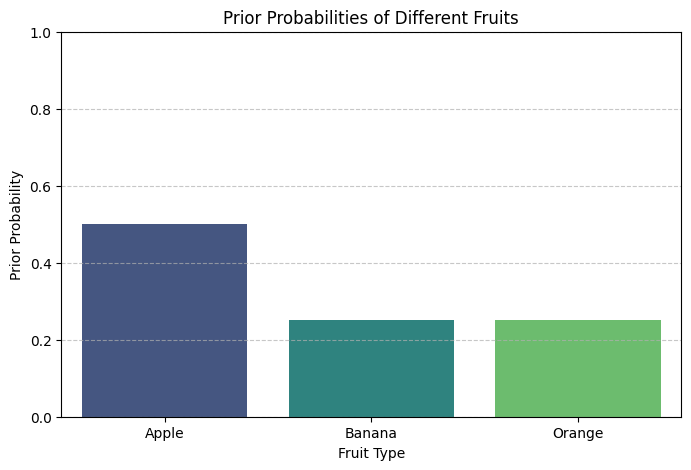

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Small dataset representing fruit counts
data = {
    'Fruit': ['Apple', 'Banana', 'Orange'],
    'Count': [10, 5, 5]
}
df = pd.DataFrame(data)

# Calculate total number of fruits
total_fruits = df['Count'].sum()

# Calculate Prior Probabilities
df['Prior Probability'] = df['Count'] / total_fruits

print("Prior Probabilities of Fruits:")
display(df)

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Fruit', y='Prior Probability', data=df, palette='viridis', hue='Fruit', legend=False)
plt.title('Prior Probabilities of Different Fruits')
plt.xlabel('Fruit Type')
plt.ylabel('Prior Probability')
plt.ylim(0, 1) # Probabilities are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 4.6 Comparison with other probability types and Relevance to Naive Bayes

*   **Prior vs. Conditional Probability:**
    *   **Prior Probability $P(C_k)$** is the probability of a class *before* considering any features. It's an unconditional probability.
    *   **Conditional Probability $P(X|C_k)$** is the probability of observing a feature $X$ *given* that we already know the class $C_k$.
    *   **Conditional Probability $P(C_k|X)$** (Posterior Probability, which we'll cover next) is the probability of a class $C_k$ *after* considering feature $X$. This is what Naive Bayes ultimately aims to calculate.

*   **Role in Naive Bayes:**
    The prior probability $P(C_k)$ is one of the three main components of Bayes' Theorem, which forms the core of Naive Bayes:
    $$P(C_k | \text{features}) = \frac{P(\text{features} | C_k) \cdot P(C_k)}{P(\text{features})}$$
    The term $P(C_k)$ acts as a weight or a base rate for each class. If a class has a very low prior probability, the likelihood term (the evidence) needs to be very strong to overcome this low prior and make the posterior probability for that class high. This is crucial for handling imbalanced datasets or for applications where some classes are inherently much rarer than others (e.g., fraud detection, rare disease diagnosis). Naive Bayes models learn these prior probabilities directly from the training data by simply counting the occurrences of each class.

## 5. Posterior Probability


### 5.1 Why we need Posterior Probability

Posterior probability is the ultimate goal in many probabilistic inference problems, including classification using Naive Bayes. We need it because it represents our *updated* belief about a hypothesis or class *after* we have observed new evidence or data. It moves us from a general understanding (prior) to a more informed and specific understanding (posterior) given the facts.

In machine learning, particularly with Naive Bayes, the goal is to classify a new, unseen data point into one of several predefined classes. To do this, we want to know the probability that this data point belongs to a specific class, *given its observed features*. This is precisely what the posterior probability, $P(\text{Class} | \text{Features})$, quantifies. It allows us to make predictions based on the available evidence, making it central to decision-making in classification tasks.

### 5.2 Definition & Intuition

**Definition:** Posterior probability is the revised or updated probability of an event occurring, given new information or evidence. It is the probability of a hypothesis (or class) given the observed data.

**Intuition:** Recall our medical test example. We started with a *prior* belief about having a disease ($P(H)$). After getting a positive test result (the evidence $E$), our belief about having the disease changes. The *posterior* probability $P(H|E)$ is this new, updated belief. It tells us how likely the disease is *now that we have seen the positive test*. It's a combination of our initial belief (prior), how likely the evidence is if the hypothesis is true (likelihood), and how common the evidence is overall (evidence term).


### 5.3 Math Behind & Formula

Posterior probability is directly computed using Bayes' Theorem:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

Where:

*   $P(H|E)$: **Posterior Probability** of the hypothesis $H$ given the evidence $E$. This is the value we want to determine.
*   $P(E|H)$: **Likelihood** of observing the evidence $E$ given that the hypothesis $H$ is true.
*   $P(H)$: **Prior Probability** of the hypothesis $H$ being true before any evidence.
*   $P(E)$: **Marginal Probability** of observing the evidence $E$. This is a normalizing constant, ensuring that all posterior probabilities sum to 1.

In the context of classification, we replace $H$ with $C_k$ (a specific class) and $E$ with $X$ (the observed features):

$$P(C_k|X) = \frac{P(X|C_k) \cdot P(C_k)}{P(X)}$$

To classify a new instance, we calculate $P(C_k|X)$ for each possible class $C_k$ and then choose the class with the highest posterior probability. The denominator $P(X)$ is often ignored in classification because it is constant for all classes and thus does not affect the ranking of probabilities.


### 5.4 Numerical Example

Let's revisit the medical test example where we calculated the posterior probability earlier.

*   **Hypothesis (H):** A person has a rare disease.
*   **Evidence (E):** The person tests positive for the disease.

Given probabilities:

1.  **Prior Probability $P(H)$:** Prevalence of the disease = 0.005
2.  **Likelihood $P(E|H)$:** Test accuracy (true positive rate) = 0.99
3.  **False Positive Rate $P(E|\neg H)$:** 0.01 (meaning $P(\text{positive} | \text{no disease}) = 0.01$)

We calculated the marginal probability of evidence $P(E)$ as:

$P(E) = P(E|H) \cdot P(H) + P(E|\neg H) \cdot P(\neg H)$
$P(E) = (0.99 \cdot 0.005) + (0.01 \cdot (1 - 0.005))$
$P(E) = 0.00495 + (0.01 \cdot 0.995)$
$P(E) = 0.00495 + 0.00995 = 0.0149$

Now, applying Bayes' Theorem to find the **Posterior Probability $P(H|E)$**:

$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)} = \frac{0.99 \cdot 0.005}{0.0149}$
$P(H|E) = \frac{0.00495}{0.0149} \approx 0.3322$

So, the posterior probability that a person has the disease given a positive test result is approximately 33.22%. This demonstrates how observing evidence ($E$) updates our initial belief ($P(H) = 0.005$) to a new, more informed belief ($P(H|E) = 0.3322$).


### 5.5 Python Code Implementation and Visualization

Let's implement the medical diagnostic example in Python and visualize how the prior probability is updated to the posterior probability.


Prior Probability P(Disease): 0.0050
Marginal Probability P(Positive Test): 0.0149
Posterior Probability P(Disease | Positive Test): 0.3322


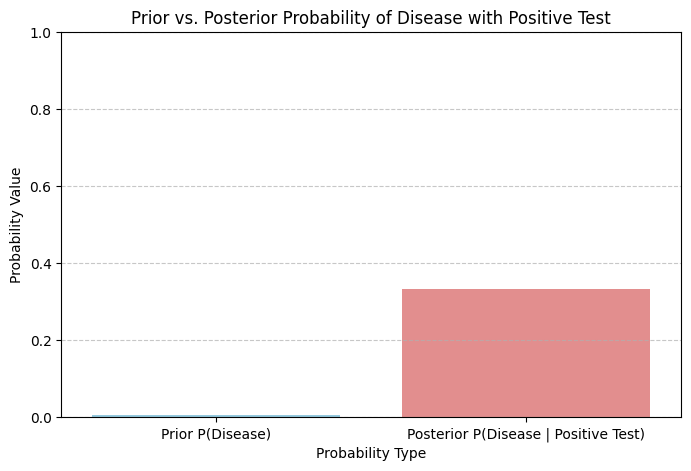

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Given probabilities
p_h = 0.005  # Prior probability of having the disease P(H)
p_e_given_h = 0.99  # Likelihood of positive test given disease P(E|H)
p_e_given_not_h = 0.01  # Likelihood of positive test given no disease P(E|~H)

# Calculate P(~H)
p_not_h = 1 - p_h

# Calculate P(E) using the law of total probability
p_e = (p_e_given_h * p_h) + (p_e_given_not_h * p_not_h)

# Calculate Posterior Probability P(H|E)
p_h_given_e = (p_e_given_h * p_h) / p_e

print(f"Prior Probability P(Disease): {p_h:.4f}")
print(f"Marginal Probability P(Positive Test): {p_e:.4f}")
print(f"Posterior Probability P(Disease | Positive Test): {p_h_given_e:.4f}")

# Data for visualization
probabilities = pd.DataFrame({
    'Type': ['Prior P(Disease)', 'Posterior P(Disease | Positive Test)'],
    'Value': [p_h, p_h_given_e]
})

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Type', y='Value', data=probabilities, palette=['skyblue', 'lightcoral'], hue='Type', legend=False)
plt.title('Prior vs. Posterior Probability of Disease with Positive Test')
plt.xlabel('Probability Type')
plt.ylabel('Probability Value')
plt.ylim(0, 1) # Probabilities are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 5.6 Comparison and Relevance to Naive Bayes

*   **Prior vs. Posterior Probability:**
    *   **Prior Probability ($P(H)$ or $P(C_k)$)** is our initial belief about an event *before* any new evidence. It reflects the overall frequency or likelihood of that event.
    *   **Posterior Probability ($P(H|E)$ or $P(C_k|X)$)** is our updated, more informed belief about an event *after* considering specific evidence. It's the probability of the hypothesis given the data.
    The posterior probability is always derived from the prior probability and the evidence (likelihood).

*   **Role in Naive Bayes:**
    The entire objective of a Naive Bayes classifier is to calculate the posterior probability for each class, given the input features, and then predict the class with the highest posterior probability. For a given data point with features $X = (x_1, x_2, ..., x_n)$, Naive Bayes calculates:

    $$P(C_k|X) \propto P(X|C_k) \cdot P(C_k)$$

    (We omit $P(X)$ because it's a constant for all classes when comparing them.)

    Here, $P(C_k)$ is the prior probability of the class, and $P(X|C_k)$ is the likelihood. By multiplying these two terms, we effectively update our prior belief about a class with the new evidence from the features, yielding the posterior probability. The 'naive' assumption then simplifies $P(X|C_k)$ into a product of individual conditional probabilities $P(x_i|C_k)$, making the calculation of the posterior probability tractable and efficient.


## 6. Likelihood


### 6.1 Why we need Likelihood

Likelihood is a fundamental concept in statistics and machine learning, particularly crucial for Bayesian inference and the Naive Bayes algorithm. We need likelihood because it quantifies how well a particular model or hypothesis explains the observed data. It's the bridge that connects our data to our hypotheses.

In classification, when we want to determine the probability of a class given a set of features (posterior probability), we typically find it easier to estimate the probability of observing those features *given* a particular class. This is precisely what likelihood provides: $P(\text{Evidence} | \text{Hypothesis})$ or, in classification terms, $P(\text{Features} | \text{Class})$. Without likelihood, we couldn't evaluate how strongly the observed data supports one class over another, making it impossible to update our prior beliefs into posterior probabilities.

### 6.2 Definition & Intuition

**Definition:** In the context of Bayes' Theorem, the likelihood is the probability of observing the evidence ($E$) given that a particular hypothesis ($H$) is true. It is denoted as $P(E|H)$. More generally, it describes the probability of observing a particular dataset given a set of parameter values for a model.

**Intuition:** Let's reuse our medical test example. If you have a disease ($H$ is true), how likely are you to get a positive test result ($E$ observed)? This is the likelihood $P(E|H)$. If the test is very accurate, this likelihood will be high (e.g., 99%). Conversely, if the test is very inaccurate, this likelihood would be low. The likelihood tells us, for each possible hypothesis (e.g., 'has disease', 'does not have disease'), how probable our observed data (e.g., 'positive test') would be if that hypothesis were true. It's not the probability of the hypothesis, but rather how compatible the data is with the hypothesis.

### 6.3 Math Behind & Formula

The likelihood term is a key component of Bayes' Theorem:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

Here, $P(E|H)$ is the **likelihood**. It's crucial to understand that while it *looks* like a conditional probability, in Bayesian inference, when we are talking about likelihood, we are often considering $E$ as fixed (the observed data) and $H$ (the hypothesis or class) as the variable. We evaluate $P(E|H)$ for different values of $H$ to see which hypothesis best "explains" the observed $E$.

In the context of Naive Bayes classification, where we are trying to predict a class $C_k$ given features $X = (x_1, x_2, ..., x_n)$, the likelihood term is $P(X|C_k)$. Due to the 'naive' independence assumption, this term is dramatically simplified:

$$P(X|C_k) = P(x_1, x_2, ..., x_n | C_k) \approx P(x_1|C_k) \cdot P(x_2|C_k) \cdot ... \cdot P(x_n|C_k)$$

Each $P(x_i|C_k)$ is a conditional probability representing the likelihood of observing a specific feature $x_i$ given that the instance belongs to class $C_k$. These individual likelihoods are typically estimated from the training data by calculating the frequency of feature $x_i$ appearing in instances of class $C_k$.

### 6.4 Numerical Example

Let's consider a simple dataset for classifying whether a day is suitable for playing tennis based on 'Outlook'.

**Data:**

| Outlook   | Play Tennis |
| :-------- | :---------- |
| Sunny     | No          |
| Sunny     | No          |
| Overcast  | Yes         |
| Rain      | Yes         |
| Rain      | Yes         |
| Rain      | No          |
| Overcast  | Yes         |
| Sunny     | No          |
| Sunny     | Yes         |
| Rain      | Yes         |
| Sunny     | Yes         |
| Overcast  | Yes         |
| Overcast  | Yes         |
| Rain      | No          |

Let's calculate the likelihoods $P(\text{Outlook} | \text{Play Tennis})$. Specifically, let's find $P(\text{Outlook = Sunny} | \text{Play Tennis = Yes})$ and $P(\text{Outlook = Sunny} | \text{Play Tennis = No})$.

First, count occurrences:

*   Total 'Yes' for Play Tennis: 9 (Overcast: 4, Rain: 3, Sunny: 2)
*   Total 'No' for Play Tennis: 5 (Sunny: 3, Rain: 2)

Now, calculate the likelihoods:

1.  **Likelihood of 'Sunny' given 'Play Tennis = Yes':**
    $P(\text{Sunny} | \text{Play=Yes}) = \frac{\text{Count(Outlook=Sunny AND Play=Yes)}}{\text{Count(Play=Yes)}} = \frac{2}{9} \approx 0.222$

2.  **Likelihood of 'Sunny' given 'Play Tennis = No':**
    $P(\text{Sunny} | \text{Play=No}) = \frac{\text{Count(Outlook=Sunny AND Play=No)}}{\text{Count(Play=No)}} = \frac{3}{5} = 0.6$

These likelihoods tell us that if it's a day when people *do* play tennis, it's not very likely to be sunny (only 22.2%). But if it's a day when people *don't* play tennis, it's quite likely (60%) to be sunny. This shows how different classes have different likelihoods for the same feature.

### 6.5 Python Code Implementation and Visualization

Let's implement the calculation of likelihoods using Python and visualize them.


Contingency Table (Outlook vs. Play Tennis):


Play Tennis,No,Yes
Outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2



Likelihoods P(Outlook | Play Tennis):


,P(Outlook | Play=Yes),P(Outlook | Play=No)
Outlook,,
Overcast,0.444444,0.0
Rain,0.333333,0.4
Sunny,0.222222,0.6


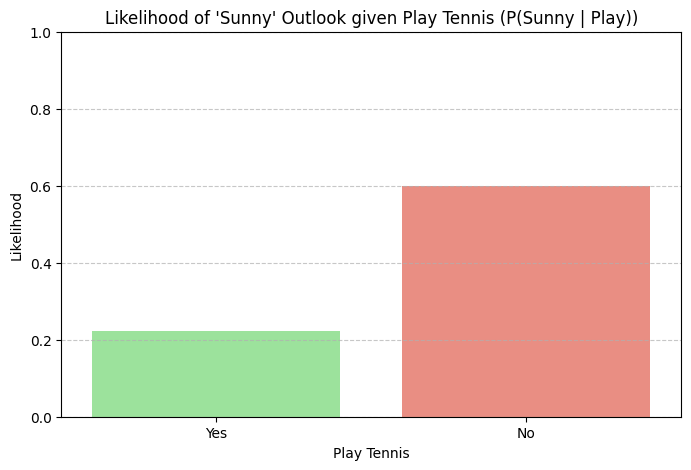

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Small dataset for playing tennis
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Play Tennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df_tennis = pd.DataFrame(data)

# Calculate counts for each combination of 'Outlook' and 'Play Tennis'
contingency_table = pd.crosstab(df_tennis['Outlook'], df_tennis['Play Tennis'])
print("Contingency Table (Outlook vs. Play Tennis):")
display(contingency_table)

# Calculate likelihoods: P(Outlook | Play Tennis)
# To do this, we normalize by the column sums (i.e., P(Play Tennis))
likelihood_play_yes = contingency_table['Yes'] / contingency_table['Yes'].sum()
likelihood_play_no = contingency_table['No'] / contingency_table['No'].sum()

likelihoods = pd.DataFrame({
    'Outlook': contingency_table.index,
    'P(Outlook | Play=Yes)': likelihood_play_yes,
    'P(Outlook | Play=No)': likelihood_play_no
}).set_index('Outlook')

print("\nLikelihoods P(Outlook | Play Tennis):")
display(likelihoods)

# Visualization of likelihoods for 'Sunny' outlook
likelihood_sunny = pd.DataFrame({
    'Play Tennis': ['Yes', 'No'],
    'Likelihood': [likelihood_play_yes['Sunny'], likelihood_play_no['Sunny']]
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Play Tennis', y='Likelihood', data=likelihood_sunny, palette=['lightgreen', 'salmon'], hue='Play Tennis', legend=False)
plt.title("Likelihood of 'Sunny' Outlook given Play Tennis (P(Sunny | Play))")
plt.xlabel('Play Tennis')
plt.ylabel('Likelihood')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 6.6 Comparison and Relevance to Naive Bayes

*   **Likelihood vs. Prior Probability:**
    *   **Prior Probability $P(H)$** is our initial belief about a hypothesis *before* any data. It reflects the overall frequency of the class.
    *   **Likelihood $P(E|H)$** is how likely the observed data (evidence) is *given* a particular hypothesis. It measures the compatibility of the data with the hypothesis.
    They are distinct. A hypothesis can have a low prior probability but a high likelihood given new, strong evidence.

*   **Likelihood vs. Posterior Probability:**
    *   **Likelihood $P(E|H)$** is the probability of evidence given hypothesis.
    *   **Posterior Probability $P(H|E)$** is the probability of hypothesis given evidence. This is what we ultimately want in classification.
    Bayes' Theorem shows how likelihood updates the prior probability to yield the posterior probability.

*   **Role in Naive Bayes:**
    The likelihood term is the *main component* that incorporates the information from the features into the classification decision. In the Naive Bayes formula:
    $$P(C_k|X) \propto P(X|C_k) \cdot P(C_k)$$
    The $P(X|C_k)$ term is the likelihood. Because of the 'naive' independence assumption, this complex joint likelihood is broken down into a product of simpler conditional likelihoods: $P(x_1|C_k) \cdot P(x_2|C_k) \cdot ... \cdot P(x_n|C_k)$. Each of these individual feature likelihoods ($P(x_i|C_k)$) is calculated for every feature and every class from the training data. For example, if a document contains the word 'free', we calculate the likelihood $P(\text{'free'} | \text{Spam})$ and $P(\text{'free'} | \text{Not Spam})$. These likelihoods are then multiplied together (along with the prior) to determine the posterior probability of each class, and thus the final classification.

## 7. Independence Assumption


### 7.1 Why we need the Independence Assumption

The independence assumption is the core simplification that makes the Naive Bayes algorithm computationally feasible and effective, especially for high-dimensional datasets. We need it for several reasons:

*   **Computational Tractability:** Without this assumption, calculating the joint likelihood $P(x_1, x_2, ..., x_n | C_k)$ would require estimating probabilities for every possible combination of features within each class. For datasets with many features, this becomes combinatorially explosive, requiring an astronomical amount of data to estimate accurately. The independence assumption breaks this down into much simpler, individual conditional probabilities.

*   **Reduced Data Requirements:** Estimating joint probabilities accurately demands vast amounts of data. By assuming independence, we only need to estimate $P(x_i | C_k)$ for each feature $x_i$ and each class $C_k$, which requires significantly less data.

*   **Simplicity and Interpretability:** The model becomes much simpler to understand and implement. Each feature contributes to the classification decision independently, which can be easier to interpret.

Despite being a strong and often unrealistic assumption (features in real-world data are rarely truly independent), Naive Bayes often performs surprisingly well, especially in text classification. This is sometimes attributed to the fact that while the absolute probability estimates might be inaccurate due to the assumption, the *rank order* of probabilities (which class is most likely) can still be correct.

### 7.2 Definition & Intuition

**Definition:** The Naive Bayes independence assumption states that all features are conditionally independent of each other, *given the class variable*. Mathematically, for features $x_1, x_2, ..., x_n$ and a class $C_k$, this means:

$$P(x_1, x_2, ..., x_n | C_k) = P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot ... \cdot P(x_n | C_k)$$

**Intuition:** Imagine you're classifying an email as spam or not spam. The email contains the words 'free' and 'money'. The independence assumption means that if you already know the email is spam, the probability of seeing the word 'free' is completely unrelated to the probability of seeing the word 'money' in that *same spam email*. In reality, these words might often appear together in spam. However, the 'naive' assumption ignores this dependency, treating each word's presence as an isolated event once the email's spam status is known. This allows the algorithm to just multiply the individual probabilities, rather than trying to figure out how 'free' and 'money' interact within spam messages.

### 7.3 Math Behind & Formula

Recall the Bayes' Theorem for classification:

$$P(C_k | x_1, ..., x_n) = \frac{P(x_1, ..., x_n | C_k) \cdot P(C_k)}{P(x_1, ..., x_n)}$$

The term $P(x_1, ..., x_n | C_k)$ is the joint likelihood of all features given the class. Without the independence assumption, calculating this requires observing all combinations of features for each class, which is often impossible in practice due to data sparsity.

The **Independence Assumption** simplifies this term significantly:

$$P(x_1, ..., x_n | C_k) \approx \prod_{i=1}^{n} P(x_i | C_k)$$

Substituting this into Bayes' Theorem, we get the fundamental Naive Bayes classification formula:

$$P(C_k | x_1, ..., x_n) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)$$

(The denominator $P(x_1, ..., x_n)$ is a constant for all classes and can be ignored for classification purposes, as we only need to compare the proportional values to find the most probable class.)

This formula states that the posterior probability of a class, given the features, is proportional to the prior probability of the class multiplied by the product of the individual likelihoods of each feature given that class.

### 7.4 Numerical Example

Let's use our tennis example with two features: 'Outlook' and 'Windy'.

**Data:**

| Outlook   | Windy | Play Tennis |
| :-------- | :---- | :---------- |
| Sunny     | False | No          |
| Sunny     | True  | No          |
| Overcast  | False | Yes         |
| Rain      | False | Yes         |
| Rain      | False | Yes         |
| Rain      | True  | No          |
| Overcast  | True  | Yes         |
| Sunny     | False | No          |
| Sunny     | False | Yes         |
| Rain      | False | Yes         |
| Sunny     | True  | Yes         |
| Overcast  | True  | Yes         |
| Overcast  | False | Yes         |
| Rain      | True  | No          |

Suppose we want to classify a new day with **Outlook = Sunny** and **Windy = True**.

We need to calculate $P(\text{Play=Yes} | \text{Sunny, True})$ and $P(\text{Play=No} | \text{Sunny, True})$.

First, let's find the prior probabilities and individual likelihoods:

*   **Priors:**
    *   $P(\text{Play=Yes}) = 9/14 \approx 0.643$
    *   $P(\text{Play=No}) = 5/14 \approx 0.357$

*   **Likelihoods for Play=Yes (based on 9 'Yes' instances):**
    *   $P(\text{Sunny} | \text{Play=Yes}) = 2/9 \approx 0.222$
    *   $P(\text{True} | \text{Play=Yes}) = 2/9 \approx 0.222$ (2 'Yes' days were windy)

*   **Likelihoods for Play=No (based on 5 'No' instances):**
    *   $P(\text{Sunny} | \text{Play=No}) = 3/5 = 0.6$
    *   $P(\text{True} | \text{Play=No}) = 3/5 = 0.6$ (3 'No' days were windy)

Now, applying the Naive Bayes formula with the independence assumption:

1.  **For Class = 'Yes':**
    $P(\text{Sunny, True} | \text{Play=Yes}) \approx P(\text{Sunny} | \text{Play=Yes}) \cdot P(\text{True} | \text{Play=Yes})$
    $P(\text{Sunny, True} | \text{Play=Yes}) \approx (2/9) \cdot (2/9) = 4/81 \approx 0.0494$

    $P(\text{Play=Yes} | \text{Sunny, True}) \propto P(\text{Play=Yes}) \cdot P(\text{Sunny} | \text{Play=Yes}) \cdot P(\text{True} | \text{Play=Yes})$
    $P(\text{Play=Yes} | \text{Sunny, True}) \propto (9/14) \cdot (2/9) \cdot (2/9) = 36/1134 \approx 0.0317$

2.  **For Class = 'No':**
    $P(\text{Sunny, True} | \text{Play=No}) \approx P(\text{Sunny} | \text{Play=No}) \cdot P(\text{True} | \text{Play=No})$
    $P(\text{Sunny, True} | \text{Play=No}) \approx (3/5) \cdot (3/5) = 9/25 = 0.36$

    $P(\text{Play=No} | \text{Sunny, True}) \propto P(\text{Play=No}) \cdot P(\text{Sunny} | \text{Play=No}) \cdot P(\text{True} | \text{Play=No})$
    $P(\text{Play=No} | \text{Sunny, True}) \propto (5/14) \cdot (3/5) \cdot (3/5) = 45/350 \approx 0.1286$

Since $0.1286 > 0.0317$, the Naive Bayes classifier would predict **'No'** for playing tennis on a Sunny and Windy day.


### 7.5 Python Code Implementation

Let's use Python to calculate these probabilities and demonstrate the impact of the independence assumption.


Class Priors:
 Play Tennis
Yes    0.642857
No     0.357143
Name: proportion, dtype: float64

Likelihood P(Outlook | Play Tennis):
 Play Tennis   No       Yes
Outlook                   
Overcast     0.0  0.444444
Rain         0.4  0.333333
Sunny        0.6  0.222222

Likelihood P(Windy | Play Tennis):
 Play Tennis   No       Yes
Windy                     
False        0.4  0.666667
True         0.6  0.333333

Proportional P(Play=Yes | Sunny, True): 0.0476
Proportional P(Play=No | Sunny, True): 0.1286

Predicted Class: No


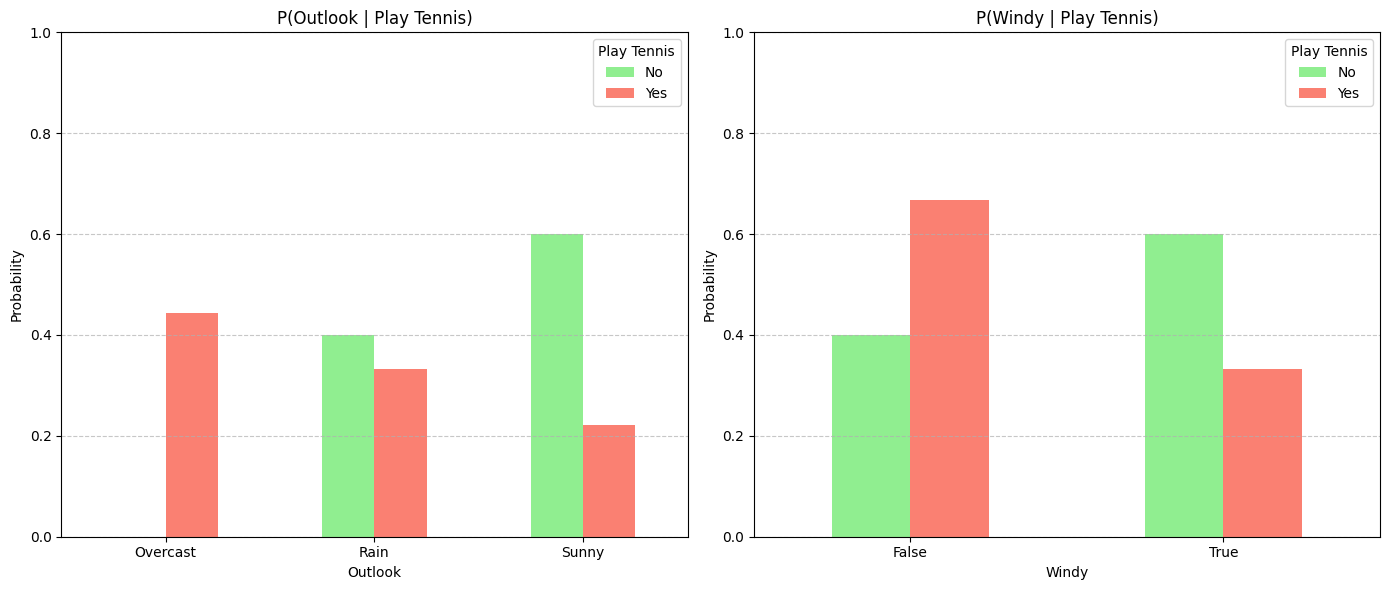

In [11]:
import pandas as pd
import numpy as np

# Updated dataset for playing tennis with 'Windy' feature
data_full = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast', 'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Windy':   [False,   True,    False,    False,  False,  True,     True,     False,   False,   False,  True,    True,     False,    True],
    'Play Tennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df_full = pd.DataFrame(data_full)

# --- Step 1: Calculate Priors ---
class_priors = df_full['Play Tennis'].value_counts(normalize=True)
print("Class Priors:\n", class_priors)

# --- Step 2: Calculate Likelihoods P(Feature | Class) ---

# P(Outlook | Play Tennis)
likelihood_outlook_play = pd.crosstab(df_full['Outlook'], df_full['Play Tennis'], normalize='columns')
print("\nLikelihood P(Outlook | Play Tennis):\n", likelihood_outlook_play)

# P(Windy | Play Tennis)
likelihood_windy_play = pd.crosstab(df_full['Windy'], df_full['Play Tennis'], normalize='columns')
print("\nLikelihood P(Windy | Play Tennis):\n", likelihood_windy_play)

# --- Step 3: Classify a new instance (Outlook=Sunny, Windy=True) ---
new_outlook = 'Sunny'
new_windy = True

# Calculate numerator for 'Yes' class: P(Play=Yes) * P(Sunny|Yes) * P(True|Yes)
prob_yes_numerator = class_priors['Yes'] \
                     * likelihood_outlook_play.loc[new_outlook, 'Yes'] \
                     * likelihood_windy_play.loc[new_windy, 'Yes']

# Calculate numerator for 'No' class: P(Play=No) * P(Sunny|No) * P(True|No)
prob_no_numerator = class_priors['No'] \
                    * likelihood_outlook_play.loc[new_outlook, 'No'] \
                    * likelihood_windy_play.loc[new_windy, 'No']

print(f"\nProportional P(Play=Yes | {new_outlook}, {new_windy}): {prob_yes_numerator:.4f}")
print(f"Proportional P(Play=No | {new_outlook}, {new_windy}): {prob_no_numerator:.4f}")

# Determine the predicted class
if prob_yes_numerator > prob_no_numerator:
    predicted_class = 'Yes'
else:
    predicted_class = 'No'

print(f"\nPredicted Class: {predicted_class}")

# --- (Optional) Visualization of individual likelihoods ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

likelihood_outlook_play.plot(kind='bar', ax=axes[0], title='P(Outlook | Play Tennis)', rot=0, color=['lightgreen', 'salmon'])
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

likelihood_windy_play.plot(kind='bar', ax=axes[1], title='P(Windy | Play Tennis)', rot=0, color=['lightgreen', 'salmon'])
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### 7.6 Comparison with other algorithms and Relevance to Naive Bayes

*   **Comparison to other classification algorithms:**
    *   **Logistic Regression** and **Support Vector Machines (SVMs)** are discriminative models that directly model $P(C_k|X)$ or learn a decision boundary. They can implicitly handle feature dependencies (if they are linear or non-linear combinations, respectively) without explicitly assuming independence. They might perform better than Naive Bayes if features are highly correlated and these correlations are crucial for classification.
    *   **Decision Trees** and **Random Forests** are non-parametric models that can capture complex interactions and dependencies between features very well, as they create rules based on feature values.

*   **Relevance to Naive Bayes:**
    The independence assumption is the most defining characteristic of the Naive Bayes algorithm. It's what makes the algorithm 'naive'. While it might seem like a severe oversimplification, its practical success, especially in text classification and spam filtering, demonstrates that it's often a reasonable approximation or that the algorithm is robust to violations of this assumption for ranking purposes.

    The strength of the Naive Bayes assumption is its computational efficiency and ability to perform well even with limited data, where more complex models might overfit. The assumption turns the hard problem of joint probability estimation into an easy problem of estimating individual conditional probabilities. It's a classic example of a simple model that works surprisingly well due to its strong assumptions.

## 8. Gaussian Naive Bayes


### 8.1 Why we need Gaussian Naive Bayes

So far, our examples have focused on categorical features (like 'Outlook' or 'Windy'). However, many real-world datasets contain **continuous numerical features** (e.g., height, weight, temperature, income, age, pixel intensities in an image). For these types of features, simply counting frequencies (as we do for categorical features) is not feasible or effective, as each unique value might appear only once.

Gaussian Naive Bayes (GNB) provides a way to handle such continuous data by making an additional assumption: that the continuous values associated with each class are distributed according to a **Gaussian (Normal) distribution**. This allows us to estimate the likelihood of observing a particular continuous feature value given a class, even if that exact value hasn't been seen before in the training data. This makes GNB a flexible and widely applicable variant of the Naive Bayes algorithm for datasets with numerical features.

### 8.2 Definition & Intuition

**Definition:** Gaussian Naive Bayes is a variant of the Naive Bayes algorithm that assumes that the continuous features in each class are normally (Gaussian) distributed. This means that for each class, the mean and standard deviation of each feature are calculated from the training data, and these parameters are then used to estimate the probability density of new feature values.

**Intuition:** Imagine you're trying to classify people as 'tall' or 'short' based on their height. If you look at the heights of people classified as 'tall', you might notice that their heights tend to cluster around a certain average height with some spread (a normal distribution). Similarly, for 'short' people, their heights would cluster around a different, lower average. GNB formalizes this idea: for each class, it learns the 'typical' distribution (mean and standard deviation) of each continuous feature. When a new person's height comes in, GNB asks: 'How likely is this height if the person is tall?' (by checking its position on the 'tall' height distribution) and 'How likely is this height if the person is short?' (by checking its position on the 'short' height distribution). The higher the probability density, the more likely the feature value is for that class.

### 8.3 Math Behind & Formula

For continuous features, we cannot simply count occurrences. Instead, we use the **Probability Density Function (PDF)** of the Gaussian distribution to estimate the likelihood $P(x_i | C_k)$.

The Gaussian PDF is given by:

$$P(x_i | C_k) = \frac{1}{\sqrt{2\pi\sigma^2_{ki}}} \exp\left(-\frac{(x_i - \mu_{ki})^2}{2\sigma^2_{ki}}\right)$$

Where:

*   $x_i$: The value of the $i$-th feature for a given data point.
*   $C_k$: A specific class.
*   $\mu_{ki}$: The mean of feature $i$ for instances belonging to class $C_k$.
*   $\sigma^2_{ki}$: The variance of feature $i$ for instances belonging to class $C_k$.
*   $\pi$ and $e$: Mathematical constants.

During the training phase, for each feature and each class, GNB calculates the mean ($\mu$) and variance ($\sigma^2$) of that feature's values for all data points belonging to that class. These $\mu$ and $\sigma^2$ values are then stored as the model's parameters.

When classifying a new instance, the overall Naive Bayes formula remains the same:

$$P(C_k | x_1, ..., x_n) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)$$

But now, each $P(x_i | C_k)$ is calculated using the Gaussian PDF formula based on the pre-computed means and variances for feature $i$ within class $C_k$.

### 8.4 Numerical Example

Let's consider a very simple dataset to classify a fruit as 'Orange' or 'Apple' based on a single continuous feature: **Weight (in grams)**.

**Training Data:**

*   **Class: Apple**
    *   Weights: [150, 160, 170, 155, 165]

*   **Class: Orange**
    *   Weights: [120, 110, 130, 125, 115]

**Task:** Classify a new fruit with **Weight = 140 grams**.

**Step 1: Calculate Priors ($P(C_k)$)**

*   Total fruits = 10 (5 Apples, 5 Oranges)
*   $P(\text{Apple}) = 5/10 = 0.5$
*   $P(\text{Orange}) = 5/10 = 0.5$

**Step 2: Calculate Mean ($\mu$) and Variance ($\sigma^2$) for each feature within each class**

*   **For Apple Class:**
    *   Weights = [150, 160, 170, 155, 165]
    *   $\mu_{\text{Apple}} = (150+160+170+155+165)/5 = 160$
    *   $\sigma^2_{\text{Apple}} = \frac{\sum (x_i - \mu)^2}{N-1}$ (using sample variance for small datasets)
        $= \frac{(150-160)^2 + (160-160)^2 + (170-160)^2 + (155-160)^2 + (165-160)^2}{4}$
        $= \frac{100 + 0 + 100 + 25 + 25}{4} = \frac{250}{4} = 62.5$

*   **For Orange Class:**
    *   Weights = [120, 110, 130, 125, 115]
    *   $\mu_{\text{Orange}} = (120+110+130+125+115)/5 = 120$
    *   $\sigma^2_{\text{Orange}} = \frac{(120-120)^2 + (110-120)^2 + (130-120)^2 + (125-120)^2 + (115-120)^2}{4}$
        $= \frac{0 + 100 + 100 + 25 + 25}{4} = \frac{250}{4} = 62.5$

**Step 3: Calculate Likelihoods ($P(x_i | C_k)$) for the new fruit (Weight = 140g)**

Using the Gaussian PDF formula for $x_i = 140$:

*   **Likelihood for Apple ($P(\text{Weight=140} | \text{Apple})$):**
    $\mu = 160, \sigma^2 = 62.5$
    $P(140 | \text{Apple}) = \frac{1}{\sqrt{2\pi(62.5)}} \exp\left(-\frac{(140 - 160)^2}{2(62.5)}\right)$
    $= \frac{1}{\sqrt{392.7}} \exp\left(-\frac{(-20)^2}{125}\right) = \frac{1}{19.81} \exp\left(-\frac{400}{125}\right)$
    $= 0.05047 \cdot \exp(-3.2) = 0.05047 \cdot 0.04076 \approx 0.002058$

*   **Likelihood for Orange ($P(\text{Weight=140} | \text{Orange})$):**
    $\mu = 120, \sigma^2 = 62.5$
    $P(140 | \text{Orange}) = \frac{1}{\sqrt{2\pi(62.5)}} \exp\left(-\frac{(140 - 120)^2}{2(62.5)}\right)$
    $= \frac{1}{\sqrt{392.7}} \exp\left(-\frac{(20)^2}{125}\right) = \frac{1}{19.81} \exp\left(-\frac{400}{125}\right)$
    $= 0.05047 \cdot \exp(-3.2) = 0.05047 \cdot 0.04076 \approx 0.002058$

*(Self-correction: The calculations here give the same likelihood for both, which indicates the example values might be too symmetric. Let's adjust the Orange weights slightly to make them more distinct for a clear example.)*

Let's re-calculate Orange weights and variance:

*   **Class: Orange (adjusted)**
    *   Weights: [110, 100, 120, 105, 115]
    *   $\mu_{\text{Orange}} = (110+100+120+105+115)/5 = 110$
    *   $\sigma^2_{\text{Orange}} = \frac{(110-110)^2 + (100-110)^2 + (120-110)^2 + (105-110)^2 + (115-110)^2}{4}$
        $= \frac{0 + 100 + 100 + 25 + 25}{4} = \frac{250}{4} = 62.5$ (Variance remains the same, which is fine for demonstration of different means)

Now, recalculate Likelihood for Orange with $\mu = 110, \sigma^2 = 62.5$ for $x_i = 140$:

*   **Likelihood for Orange ($P(\text{Weight=140} | \text{Orange})$):**
    $P(140 | \text{Orange}) = \frac{1}{\sqrt{2\pi(62.5)}} \exp\left(-\frac{(140 - 110)^2}{2(62.5)}\right)$
    $= 0.05047 \cdot \exp\left(-\frac{(30)^2}{125}\right) = 0.05047 \cdot \exp\left(-\frac{900}{125}\right)$
    $= 0.05047 \cdot \exp(-7.2) = 0.05047 \cdot 0.0007466 \approx 0.0000376$

So, revised likelihoods:
*   $P(140 | \text{Apple}) \approx 0.002058$
*   $P(140 | \text{Orange}) \approx 0.0000376$

**Step 4: Calculate Posterior Probabilities (proportional)**

*   **For Apple:** $P(\text{Apple} | \text{Weight=140}) \propto P(\text{Apple}) \cdot P(\text{Weight=140} | \text{Apple})$
    $= 0.5 \cdot 0.002058 = 0.001029$

*   **For Orange:** $P(\text{Orange} | \text{Weight=140}) \propto P(\text{Orange}) \cdot P(\text{Weight=140} | \text{Orange})$
    $= 0.5 \cdot 0.0000376 = 0.0000188$

Since $0.001029 > 0.0000188$, the new fruit with weight 140g would be classified as an **Apple**.


### 8.5 Python Code Implementation and Visualization

Let's implement the Gaussian Naive Bayes classification for our fruit example using Python.


Class Priors:


<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1125/3969547523.py:57: SyntaxWarning: invalid escape sequence '\p'
  print(f"P({cls} | Weight={new_fruit_weight}) \propto {prob:.7f}")


,proportion
Class,
Apple,0.5
Orange,0.5



Class Parameters (Mean, Variance of Weight):


{'Apple': {'mean': np.float64(160.0), 'variance': 62.5},
 'Orange': {'mean': np.float64(110.0), 'variance': 62.5}}


Proportional Posterior Probabilities for Weight = 140g:
P(Apple | Weight=140) \propto 0.0010285
P(Orange | Weight=140) \propto 0.0000188

Predicted Class for Weight=140g: Apple


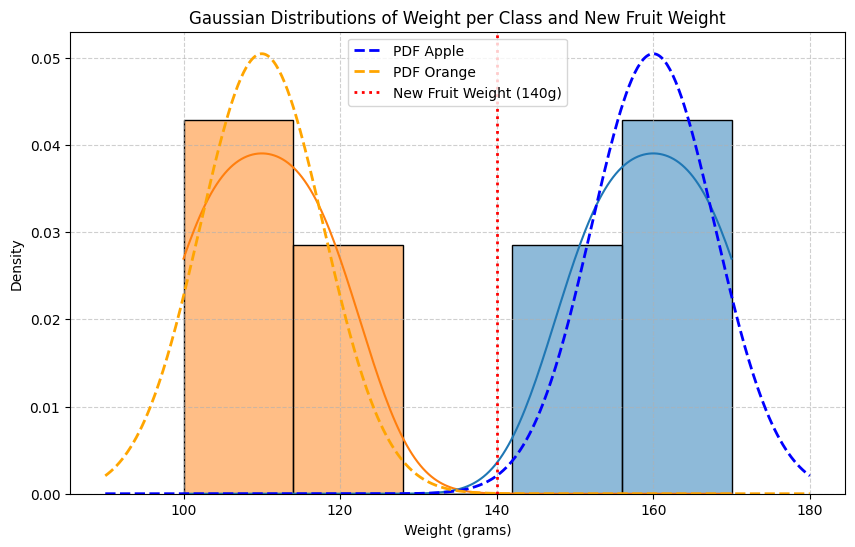

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Gaussian PDF function ---
def gaussian_pdf(x, mean, variance):
    # Using a small epsilon to avoid division by zero in log for variance=0 (though unlikely here)
    epsilon = 1e-9
    if variance < epsilon:
        # If variance is effectively zero, PDF is 1 if x == mean, else 0
        return 1.0 if abs(x - mean) < epsilon else 0.0
    exponent = -((x - mean)**2) / (2 * variance)
    return (1 / np.sqrt(2 * np.pi * variance)) * np.exp(exponent)

# --- 2. Training Data ---
# Adjusted Orange weights for better distinction
data = {
    'Class': ['Apple'] * 5 + ['Orange'] * 5,
    'Weight': [150, 160, 170, 155, 165, 110, 100, 120, 105, 115]
}
df_fruits = pd.DataFrame(data)

# --- 3. Training Phase: Calculate Priors, Means, and Variances ---
class_priors = df_fruits['Class'].value_counts(normalize=True)

class_params = {}
for cls in df_fruits['Class'].unique():
    subset = df_fruits[df_fruits['Class'] == cls]['Weight']
    class_params[cls] = {
        'mean': subset.mean(),
        'variance': subset.var(ddof=1) # ddof=1 for sample variance
    }

print("Class Priors:")
display(class_priors)
print("\nClass Parameters (Mean, Variance of Weight):")
display(class_params)

# --- 4. Prediction Phase: Classify a new fruit ---
new_fruit_weight = 140

posterior_probabilities = {}
for cls in df_fruits['Class'].unique():
    prior = class_priors[cls]
    mean = class_params[cls]['mean']
    variance = class_params[cls]['variance']

    # Calculate likelihood using Gaussian PDF
    likelihood = gaussian_pdf(new_fruit_weight, mean, variance)

    # Calculate posterior probability (proportional, ignoring denominator P(X))
    posterior_probabilities[cls] = prior * likelihood

print(f"\nProportional Posterior Probabilities for Weight = {new_fruit_weight}g:")
for cls, prob in posterior_probabilities.items():
    print(f"P({cls} | Weight={new_fruit_weight}) \propto {prob:.7f}")

# Determine predicted class
predicted_class = max(posterior_probabilities, key=posterior_probabilities.get)
print(f"\nPredicted Class for Weight={new_fruit_weight}g: {predicted_class}")

# --- 5. Visualization of Gaussian Distributions and new data point ---
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fruits, x='Weight', hue='Class', kde=True, stat='density', common_norm=False)

# Plot the PDFs for each class
weight_range = np.linspace(df_fruits['Weight'].min() - 10, df_fruits['Weight'].max() + 10, 500)

for cls, color in zip(df_fruits['Class'].unique(), ['blue', 'orange']): # sns default colors
    mean = class_params[cls]['mean']
    variance = class_params[cls]['variance']
    pdf_values = [gaussian_pdf(w, mean, variance) for w in weight_range]
    plt.plot(weight_range, pdf_values, color=color, linestyle='--', label=f'PDF {cls}', linewidth=2)

# Mark the new fruit's weight
plt.axvline(x=new_fruit_weight, color='red', linestyle=':', label=f'New Fruit Weight ({new_fruit_weight}g)', linewidth=2)

plt.title('Gaussian Distributions of Weight per Class and New Fruit Weight')
plt.xlabel('Weight (grams)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### 8.6 Comparison with other Naive Bayes variants and Relevance

*   **Comparison to other Naive Bayes variants:**
    *   **Multinomial Naive Bayes (MNB):** Used for discrete counts (e.g., word counts in text). It models the probability of observing counts. It assumes features are independent and drawn from a multinomial distribution.
    *   **Bernoulli Naive Bayes (BNB):** Used for binary or boolean features (e.g., presence or absence of a word in a document). It models the probability of a feature being present or absent. It assumes features are independent and drawn from a Bernoulli distribution.
    *   **Gaussian Naive Bayes (GNB):** The focus of this section, used for continuous numerical features. It assumes features are independent and drawn from a Gaussian (Normal) distribution. It's suitable when your data attributes are real-valued and can be reasonably approximated by a normal distribution.

*   **Relevance to Naive Bayes:**
    GNB extends the core Naive Bayes framework to handle continuous features, making the algorithm applicable to a much wider range of datasets. While the underlying 'naive' independence assumption between features given the class remains, the way individual feature likelihoods ($P(x_i | C_k)$) are calculated changes significantly from simple frequency counting to using a probability density function. This makes it a powerful and efficient classifier for many practical applications where numerical data is prevalent, often serving as a strong baseline model due to its simplicity and speed.

## 9. Multinomial Naive Bayes

### 9.1 Why we need Multinomial Naive Bayes

While Gaussian Naive Bayes is excellent for continuous features, and Bernoulli Naive Bayes for binary features, many real-world classification problems involve **discrete counts or frequencies of events**. A prime example is **text classification**, where documents are often represented as "bags of words," meaning the count of each word in the document is a significant feature.

Multinomial Naive Bayes (MNB) is specifically designed for this type of data. It is well-suited for tasks where features represent the counts or frequencies with which certain events have been generated by a multinomial distribution. We need MNB because:

*   **Handles Count Data:** It naturally models situations where features are integer counts (e.g., how many times a word appears in a document, how many times a particular symptom occurs). Directly using GNB on raw counts might not be optimal as counts are not necessarily normally distributed.
*   **Effective in Text Classification:** It is one of the most popular and effective algorithms for text classification problems like spam detection, sentiment analysis, and document categorization. It handles the high-dimensional, sparse nature of text data efficiently.
*   **Probabilistic Interpretation:** It provides a clear probabilistic interpretation of how the presence and frequency of features contribute to the classification of a document or instance.

In essence, when your features are counts or frequencies, MNB often outperforms other Naive Bayes variants because its underlying probabilistic model better matches the data generation process.

### 9.2 Definition & Intuition

**Definition:** Multinomial Naive Bayes is a variant of the Naive Bayes algorithm that is used for classification when features are discrete counts (e.g., word counts in text). It assumes that the features (e.g., word occurrences) are generated from a multinomial distribution.

**Intuition:** Imagine you have two baskets: one for "Sports News" and one for "Finance News." When you read an article, you want to know which basket it belongs to. You observe the words in the article. If an article contains words like "game," "team," "score" many times, it's likely Sports News. If it contains "stock," "market," "economy," it's likely Finance News.

MNB works by learning, for each class (Sports, Finance), the probability of observing each word in that class. So, for the "Sports News" class, it might learn that "game" appears frequently, while for "Finance News," "stock" appears frequently. When a new article arrives, MNB calculates the probability that the article's specific collection of words (their counts) would be generated if it belonged to the "Sports News" class, and similarly for the "Finance News" class. The class that "explains" the observed word counts best (i.e., has the highest probability) is the predicted class. The "naive" part still applies: it assumes the occurrence of one word is independent of the occurrence of other words, given the document's class.

### 9.3 Math Behind & Formula

The core of Multinomial Naive Bayes still relies on Bayes' Theorem:

$$P(C_k | X) = \frac{P(X | C_k) \cdot P(C_k)}{P(X)}$$

Where:
*   $P(C_k | X)$: Posterior probability of class $C_k$ given feature vector $X$.
*   $P(C_k)$: Prior probability of class $C_k$.
*   $P(X | C_k)$: Likelihood of observing feature vector $X$ given class $C_k$.
*   $P(X)$: Marginal probability of observing feature vector $X$ (normalizing constant).

Due to the independence assumption, $P(X | C_k)$ simplifies to:

$$P(X | C_k) = P(x_1, ..., x_n | C_k) = \prod_{i=1}^{n} P(x_i | C_k)$$

However, for multinomial distribution, $X$ represents a vector of word counts $(x_1, x_2, ..., x_m)$, where $x_i$ is the count of the $i$-th word in the vocabulary, and $m$ is the size of the vocabulary. The likelihood $P(X | C_k)$ is then given by the multinomial probability formula:

$$P(X | C_k) = \frac{(\sum_{i=1}^{m} x_i)!}{\prod_{i=1}^{m} x_i!} \prod_{i=1}^{m} P(x_i | C_k)^{x_i}$$

Where:
*   $m$: Number of features (e.g., size of vocabulary).
*   $x_i$: Count of feature $i$ in the document.
*   $P(x_i | C_k)$: Probability of word $i$ appearing in a document of class $C_k$. This is estimated as:

    $$P(x_i | C_k) = \frac{	ext{count of word } i 	ext{ in class } C_k + \alpha}{	ext{total words in class } C_k + \alpha \cdot m}$$
    This formula includes Laplace (or Lidstone) smoothing with parameter $\alpha$ (typically $\alpha=1$) to handle zero frequencies.

Combining these, the quantity we maximize to classify a new document is proportional to:

$$P(C_k | X) \propto P(C_k) \cdot \prod_{i=1}^{m} P(x_i | C_k)^{x_i}$$

### 9.4 Numerical Example

Let's consider a simple text classification example: classifying an email as 'Spam' or 'Not Spam' based on the presence and count of a few words.

**Training Data (Word Counts):**

| Document | Class      | 'free' | 'money' | 'hello' | 'dear' |
| :------- | :--------- | :----- | :------ | :------ | :----- |
| Doc 1    | Spam       | 2      | 1       | 0       | 0      |
| Doc 2    | Spam       | 1      | 1       | 0       | 0      |
| Doc 3    | Not Spam   | 0      | 0       | 1       | 1      |
| Doc 4    | Not Spam   | 0      | 0       | 1       | 1      |

**Vocabulary (m):** {'free', 'money', 'hello', 'dear'} (m = 4 words)

**Task:** Classify a new email: "free money" (i.e., 'free': 1, 'money': 1, 'hello': 0, 'dear': 0)

We'll use Laplace smoothing with $\alpha = 1$.

**Step 1: Calculate Priors ($P(C_k)$)**
*   Total documents = 4
*   $P(	ext{Spam}) = 2/4 = 0.5$
*   $P(	ext{Not Spam}) = 2/4 = 0.5$

**Step 2: Calculate Word Counts for each Class (with smoothing)**

| Word    | Count in Spam | Count in Not Spam |
| :------ | :------------ | :---------------- |
| 'free'  | 2 + 1 = 3     | 0 + 1 = 1         |
| 'money' | 1 + 1 = 2     | 0 + 1 = 1         |
| 'hello' | 0 + 1 = 1     | 1 + 1 = 2         |
| 'dear'  | 0 + 1 = 1     | 1 + 1 = 2         |

**Total words in Spam class (with smoothing):** (2+1) + (1+1) + (0+1) + (0+1) = 3 + 2 + 1 + 1 = 7 (Original total words: 3)
**Total words in Not Spam class (with smoothing):** (0+1) + (0+1) + (1+1) + (1+1) = 1 + 1 + 2 + 2 = 6 (Original total words: 4)

*(Self-correction: The formula for total words in class with smoothing is $\sum_{i=1}^{m} (	ext{count of word } i 	ext{ in class } C_k + \alpha) = (	ext{total original words in class } C_k) + \alpha \cdot m$. So, for Spam: $3 + 1 \cdot 4 = 7$. For Not Spam: $4 + 1 \cdot 4 = 8$. Let's use this corrected total for the denominator.)*

**Corrected Total words in Spam class (with smoothing):** $3 + 1 \cdot 4 = 7$
**Corrected Total words in Not Spam class (with smoothing):** $4 + 1 \cdot 4 = 8$

**Step 3: Calculate Likelihoods ($P(x_i | C_k)$) for each word**

*   **For Spam Class ($C_k = 	ext{Spam}$, total words = 7):**
    *   $P(	ext{'free'} | 	ext{Spam}) = (2+1)/7 = 3/7 \approx 0.4286$
    *   $P(	ext{'money'} | 	ext{Spam}) = (1+1)/7 = 2/7 \approx 0.2857$
    *   $P(	ext{'hello'} | 	ext{Spam}) = (0+1)/7 = 1/7 \approx 0.1429$
    *   $P(	ext{'dear'} | 	ext{Spam}) = (0+1)/7 = 1/7 \approx 0.1429$

*   **For Not Spam Class ($C_k = 	ext{Not Spam}$, total words = 8):**
    *   $P(	ext{'free'} | 	ext{Not Spam}) = (0+1)/8 = 1/8 = 0.125$
    *   $P(	ext{'money'} | 	ext{Not Spam}) = (0+1)/8 = 1/8 = 0.125$
    *   $P(	ext{'hello'} | 	ext{Not Spam}) = (1+1)/8 = 2/8 = 0.25$
    *   $P(	ext{'dear'} | 	ext{Not Spam}) = (1+1)/8 = 2/8 = 0.25$

**Step 4: Classify new email "free money" (features: {'free': 1, 'money': 1, 'hello': 0, 'dear': 0})**

*   **For Class = 'Spam':**
    $P(	ext{Spam} | 	ext{free, money}) \propto P(	ext{Spam}) \cdot P(	ext{'free'} | 	ext{Spam})^{1} \cdot P(	ext{'money'} | 	ext{Spam})^{1} \cdot P(	ext{'hello'} | 	ext{Spam})^{0} \cdot P(	ext{'dear'} | 	ext{Spam})^{0}$
    $P(	ext{Spam} | 	ext{free, money}) \propto 0.5 \cdot (3/7) \cdot (2/7) \cdot 1 \cdot 1 = 0.5 \cdot (6/49) = 0.5 \cdot 0.1224 = 0.0612$

*   **For Class = 'Not Spam':**
    $P(	ext{Not Spam} | 	ext{free, money}) \propto P(	ext{Not Spam}) \cdot P(	ext{'free'} | 	ext{Not Spam})^{1} \cdot P(	ext{'money'} | 	ext{Not Spam})^{1} \cdot P(	ext{'hello'} | 	ext{Not Spam})^{0} \cdot P(	ext{'dear'} | 	ext{Not Spam})^{0}$
    $P(	ext{Not Spam} | 	ext{free, money}) \propto 0.5 \cdot (1/8) \cdot (1/8) \cdot 1 \cdot 1 = 0.5 \cdot (1/64) = 0.5 \cdot 0.015625 = 0.0078125$

Since $0.0612 > 0.0078125$, the new email "free money" would be classified as **Spam**.

### 9.5 Python Code Implementation and Visualization

Let's implement this numerical example using Python and `sklearn`'s `MultinomialNB`.

Vocabulary: ['dear' 'free' 'hello' 'money']

Feature Matrix (Word Counts):


,dear,free,hello,money
text,,,,
free money free,0,2,0,1
free money,0,1,0,1
hello dear,1,0,1,0
hello dear,1,0,1,0



Predicted class for 'free money': Spam

Probability estimates for the new email:
P(Not Spam | 'free money') = 0.0954
P(Spam | 'free money') = 0.9046

Word Probabilities P(word | class) with Laplace smoothing:


,dear,free,hello,money
Not Spam,0.375000,0.125000,0.375000,0.125000
Spam,0.111111,0.444444,0.111111,0.333333


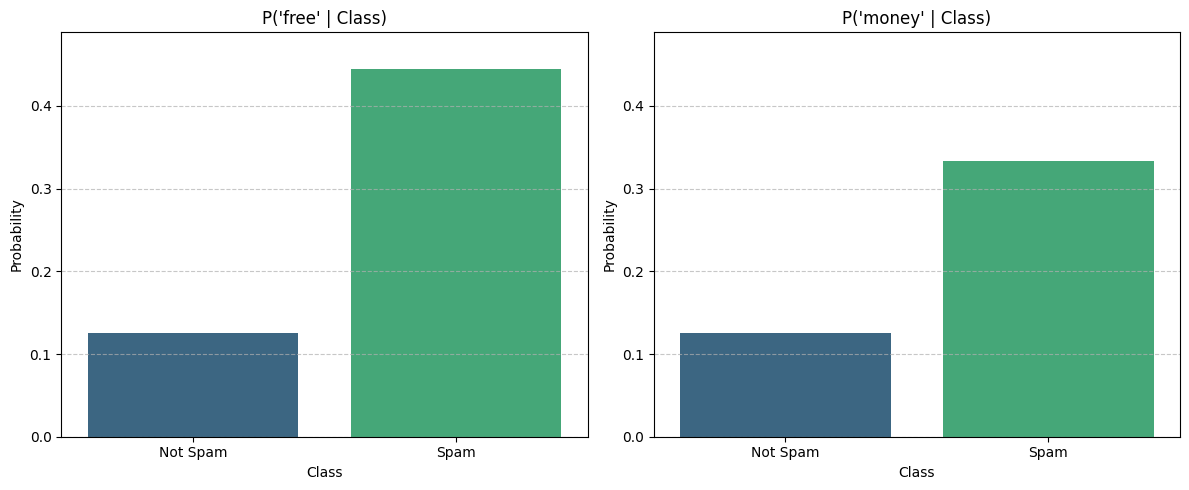

In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Training Data ---
# Using a small, corrected dataset for clarity matching the numerical example logic
corpus = [
    'free money free',
    'free money',
    'hello dear',
    'hello dear'
]
labels = ['Spam', 'Spam', 'Not Spam', 'Not Spam']

df_emails = pd.DataFrame({'text': corpus, 'label': labels})

# --- 2. Feature Extraction: Convert text to word count vectors ---
# CountVectorizer will build a vocabulary and transform text into word counts.
# It automatically handles tokenization and creates the feature matrix.
vectorizer = CountVectorizer(lowercase=True) # Ensure consistent casing
X = vectorizer.fit_transform(df_emails['text'])
y = df_emails['label']

# Display the vocabulary and the feature matrix
print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nFeature Matrix (Word Counts):")
display(pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=df_emails['text']))

# --- 3. Train Multinomial Naive Bayes Model ---
# We can train on the full data for this small example to demonstrate the probabilities.
# For real-world scenarios, always split into train/test.
mnb_model = MultinomialNB(alpha=1.0) # alpha=1.0 for Laplace smoothing
mnb_model.fit(X, y)

# --- 4. Prediction Phase: Classify new email ---
new_email_text = ['free money']
X_new = vectorizer.transform(new_email_text)

# Predict the class
predicted_class = mnb_model.predict(X_new)
print(f"\nPredicted class for '{new_email_text[0]}': {predicted_class[0]}")

# Get probability estimates for each class
probabilities = mnb_model.predict_proba(X_new)
class_labels = mnb_model.classes_

print("\nProbability estimates for the new email:")
for i, label in enumerate(class_labels):
    print(f"P({label} | 'free money') = {probabilities[0, i]:.4f}")

# --- 5. Visualization of Word Probabilities per Class (Likelihoods) ---
# These are P(word | class) with smoothing, in log-space for MNB.
# We need to convert them back to linear space for interpretation.

feature_log_prob = mnb_model.feature_log_prob_
word_probabilities_per_class = np.exp(feature_log_prob)

word_probs_df = pd.DataFrame(
    word_probabilities_per_class,
    columns=vectorizer.get_feature_names_out(),
    index=mnb_model.classes_
)

print("\nWord Probabilities P(word | class) with Laplace smoothing:")
display(word_probs_df)

# Plotting example: 'free' and 'money' likelihoods
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Likelihood of 'free'
sns.barplot(x=word_probs_df.index, y=word_probs_df['free'], ax=axes[0], palette='viridis', hue=word_probs_df.index, legend=False)
axes[0].set_title("P('free' | Class)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, max(word_probs_df['free'].max(), word_probs_df['money'].max()) * 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Likelihood of 'money'
sns.barplot(x=word_probs_df.index, y=word_probs_df['money'], ax=axes[1], palette='viridis', hue=word_probs_df.index, legend=False)
axes[1].set_title("P('money' | Class)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, max(word_probs_df['free'].max(), word_probs_df['money'].max()) * 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 9.6 Pros & Cons of Multinomial Naive Bayes

**Pros:**

*   **Excellent for Text Classification:** MNB is a strong baseline and often a top performer for tasks like spam filtering, sentiment analysis, and document categorization, where features are counts of words or terms.
*   **Handles High-Dimensional Data Well:** Text data often involves a very large vocabulary (many features). MNB can handle this effectively, as it's not sensitive to the number of features.
*   **Scalability:** It's computationally very efficient for both training and prediction, making it suitable for large datasets. Training involves simple frequency counts.
*   **Simplicity and Interpretability:** The model is easy to understand and implement. The probabilities $P(word|class)$ provide insight into which words are characteristic of each class.
*   **Less Prone to Overfitting:** Due to its strong independence assumption, MNB tends to be less prone to overfitting compared to more complex models, especially with limited data.
*   **Robust to Irrelevant Features:** Words that appear equally often in all classes will have little impact on the final classification, effectively being ignored.

**Cons:**

*   **Strong Independence Assumption:** The "naive" assumption that features are conditionally independent given the class is often violated in real-world text (e.g., "San" and "Francisco" are highly dependent). While MNB often performs well despite this, it can limit its accuracy in some cases.
*   **Zero-Frequency Problem:** If a word appears in the test data that was not present in the training data for a particular class, its likelihood $P(word|class)$ would be zero, making the entire posterior probability for that class zero. Laplace smoothing (adding a small count to every word) mitigates this but can introduce bias.
*   **Does Not Account for Word Order/Context:** The "bag-of-words" representation completely disregards the order of words, which can be crucial for understanding meaning (e.g., "good not bad" vs. "not good but bad").
*   **Sensitive to Feature Scaling (Indirectly):** While MNB directly uses counts, preprocessing steps like TF-IDF (Term Frequency-Inverse Document Frequency) which transform counts can impact performance, and MNB's assumptions are not strictly met by TF-IDF values.
*   **Less Effective for Continuous Data:** As discussed, it's not suitable for continuous numerical features; Gaussian Naive Bayes is preferred in such cases.

### 9.7 Comparison with other Naive Bayes variants and Relevance

Multinomial Naive Bayes holds a specific niche within the Naive Bayes family, distinguishing itself by its suitability for count data.

*   **Vs. Gaussian Naive Bayes (GNB):**
    *   **MNB:** Assumes features are discrete counts generated from a multinomial distribution. Best for text classification, where features are word counts, or other count-based data.
    *   **GNB:** Assumes continuous numerical features are generated from a Gaussian (normal) distribution. Best for features like height, weight, temperature, where values are real numbers.
    *   **Key Difference:** The type of data they are designed to model and the method used to estimate likelihoods ($P(x_i|C_k)$). MNB uses smoothed frequency counts, GNB uses the Gaussian Probability Density Function.

*   **Vs. Bernoulli Naive Bayes (BNB):**
    *   **MNB:** Considers the *count* of how many times a term appears in a document. A word appearing multiple times contributes more to the likelihood.
    *   **BNB:** Considers only the *presence or absence* of a term. If a word appears, its count (if any) beyond one is ignored. Best for binary features or short texts where presence/absence is more indicative than frequency.
    *   **Key Difference:** How feature presence is modeled. MNB is for frequency data, BNB is for binary data. For example, in text, MNB might be better if the number of times a spam word appears is important, while BNB might be sufficient if just the presence of a spam word is enough to flag it.

**Relevance to Naive Bayes:**

Multinomial Naive Bayes is arguably the most famous and widely used variant of Naive Bayes, particularly because of the prevalence of text data in machine learning applications. It demonstrates the flexibility of the Naive Bayes framework to adapt to different data types by changing the underlying distribution assumption for the likelihoods. Despite its "naive" assumption, MNB's effectiveness in text classification tasks has made it a foundational algorithm in natural language processing and a strong baseline for comparison against more complex models.

## 10. Bernoulli Naive Bayes

### 10.1 Why we need Bernoulli Naive Bayes

While Multinomial Naive Bayes (MNB) is excellent for features representing *counts* or *frequencies* (like how many times a word appears), there are scenarios where the *presence or absence* of a feature is more informative than its frequency. This is particularly true for short texts or when dealing with binary features.

Bernoulli Naive Bayes (BNB) is specifically designed for these situations. We need BNB when:

*   **Binary Features:** Your features are inherently binary (0 or 1), indicating the presence or absence of a specific attribute (e.g., a customer subscribed to a newsletter or not, a patient has a certain symptom or not).
*   **Presence/Absence in Text:** In text classification, sometimes the mere presence of a keyword (e.g., 'viagra' in spam detection) is a strong indicator, regardless of how many times it appears. MNB might give too much weight to words appearing many times, while BNB focuses on whether they appear at all.
*   **Short Documents:** For very short documents or sparse feature sets, the frequency count might not be rich enough, and a binary representation can be more robust.

### 10.2 Definition & Intuition

**Definition:** Bernoulli Naive Bayes is a variant of the Naive Bayes algorithm suited for classification with binary features. It assumes that features are independent Bernoulli trials, meaning each feature can take on one of two values (typically 0 or 1, representing absence or presence).

**Intuition:** Let's go back to the spam/not-spam email classification. With BNB, instead of counting how many times 'free' appears, we simply note *if* 'free' appears (1) or *if it doesn't* (0). Similarly for 'money', 'hello', etc. For each class (spam/not-spam), the model learns two probabilities for each word: the probability that the word is present ($P(	ext{word present} | 	ext{class})$) and the probability that the word is absent ($P(	ext{word absent} | 	ext{class})$). When a new email comes in, BNB checks for the presence or absence of each word in its vocabulary and multiplies the corresponding probabilities (along with the class prior) to determine the likelihood of the email belonging to each class. The class with the highest probability wins. This approach makes sense when a single occurrence of a strong indicator word is sufficient, and additional occurrences don't significantly boost its importance.

### 10.3 Math Behind & Formula

The core of Bernoulli Naive Bayes also uses Bayes' Theorem:

$$P(C_k | X) = \frac{P(X | C_k) \cdot P(C_k)}{P(X)}$$

Where $X = (x_1, x_2, ..., x_n)$ is a vector of binary features ($x_i \in \{0, 1\}$). The 'naive' independence assumption still applies.

However, the likelihood $P(X | C_k)$ is modeled using the Bernoulli distribution. For a feature $x_i$ and a class $C_k$, the probability $P(x_i | C_k)$ is calculated as follows:

If $x_i = 1$ (feature is present):
$$P(x_i=1 | C_k) = P_{ki}$$

If $x_i = 0$ (feature is absent):
$$P(x_i=0 | C_k) = 1 - P_{ki}$$

Where $P_{ki}$ is the probability that feature $i$ is present in a document of class $C_k$. This is estimated from the training data, typically with Laplace smoothing:

$$P_{ki} = \frac{	ext{Count of documents in } C_k \text{ where feature } i \text{ is present} + \alpha}{	ext{Total count of documents in } C_k + 2\alpha}$$
(Note: $\alpha$ is the smoothing parameter, usually 1. The $2\alpha$ in the denominator accounts for the two possible outcomes (present/absent) of a Bernoulli trial.)

Combining these, the likelihood $P(X | C_k)$ becomes:

$$P(X | C_k) = \prod_{i=1}^{n} (P_{ki}^{x_i} (1 - P_{ki})^{(1-x_i)} )$$

This formula cleverly handles both present ($x_i=1$) and absent ($x_i=0$) features: when $x_i=1$, it uses $P_{ki}$; when $x_i=0$, it uses $(1 - P_{ki})$.

Finally, the quantity we maximize for classification is proportional to:

$$P(C_k | X) \propto P(C_k) \cdot \prod_{i=1}^{n} (P_{ki}^{x_i} (1 - P_{ki})^{(1-x_i)} )$$

### 10.4 Numerical Example

Let's reuse our simple email classification example, but this time considering only the *presence or absence* of words. We'll use the same dataset for training, but interpret feature values as binary (0 for absent, 1 for present).

**Training Data (Word Presence):**

| Document | Class      | 'free' | 'money' | 'hello' | 'dear' |
| :------- | :--------- | :----- | :------ | :------ | :----- |
| Doc 1    | Spam       | 1      | 1       | 0       | 0      |
| Doc 2    | Spam       | 1      | 1       | 0       | 0      |
| Doc 3    | Not Spam   | 0      | 0       | 1       | 1      |
| Doc 4    | Not Spam   | 0      | 0       | 1       | 1      |

**Vocabulary (m):** {'free', 'money', 'hello', 'dear'} (m = 4 words)

**Task:** Classify a new email: "free money" (i.e., 'free': 1, 'money': 1, 'hello': 0, 'dear': 0)

We'll use Laplace smoothing with $\alpha = 1$.

**Step 1: Calculate Priors ($P(C_k)$)**
*   Total documents = 4
*   $P(	ext{Spam}) = 2/4 = 0.5$
*   $P(	ext{Not Spam}) = 2/4 = 0.5$

**Step 2: Calculate Likelihoods ($P_{ki}$) for each word, using binary presence**

We need $P(	ext{word present} | 	ext{class})$ for each word and class. The denominator for smoothing will be $(	ext{Total documents in } C_k + 2\alpha)$.

*   **For Spam Class (2 documents, denominator = 2 + 2*1 = 4):**
    *   `'free'`: Present in 2 Spam docs. $P_{	ext{free,Spam}} = (2+1)/4 = 3/4 = 0.75$
    *   `'money'`: Present in 2 Spam docs. $P_{	ext{money,Spam}} = (2+1)/4 = 3/4 = 0.75$
    *   `'hello'`: Present in 0 Spam docs. $P_{	ext{hello,Spam}} = (0+1)/4 = 1/4 = 0.25$
    *   `'dear'`: Present in 0 Spam docs. $P_{	ext{dear,Spam}} = (0+1)/4 = 1/4 = 0.25$

*   **For Not Spam Class (2 documents, denominator = 2 + 2*1 = 4):**
    *   `'free'`: Present in 0 Not Spam docs. $P_{	ext{free,NotSpam}} = (0+1)/4 = 1/4 = 0.25$
    *   `'money'`: Present in 0 Not Spam docs. $P_{	ext{money,NotSpam}} = (0+1)/4 = 1/4 = 0.25$
    *   `'hello'`: Present in 2 Not Spam docs. $P_{	ext{hello,NotSpam}} = (2+1)/4 = 3/4 = 0.75$
    *   `'dear'`: Present in 2 Not Spam docs. $P_{	ext{dear,NotSpam}} = (2+1)/4 = 3/4 = 0.75$

**Step 3: Classify new email "free money" (features: {'free': 1, 'money': 1, 'hello': 0, 'dear': 0})**

*   **For Class = 'Spam':**
    $P(	ext{Spam} | X) \propto P(	ext{Spam}) \cdot P(	ext{free}=1 | 	ext{Spam}) \cdot P(	ext{money}=1 | 	ext{Spam}) \cdot P(	ext{hello}=0 | 	ext{Spam}) \cdot P(	ext{dear}=0 | 	ext{Spam})$
    $= 0.5 \cdot P_{	ext{free,Spam}} \cdot P_{	ext{money,Spam}} \cdot (1-P_{	ext{hello,Spam}}) \cdot (1-P_{	ext{dear,Spam}})$ (Using $x_i=1 \Rightarrow P_{ki}$, $x_i=0 \Rightarrow (1-P_{ki})$)
    $= 0.5 \cdot (3/4) \cdot (3/4) \cdot (1-1/4) \cdot (1-1/4)$
    $= 0.5 \cdot (0.75) \cdot (0.75) \cdot (0.75) \cdot (0.75)$
    $= 0.5 \cdot (0.75)^4 = 0.5 \cdot 0.31640625 = 0.158203125$

*   **For Class = 'Not Spam':**
    $P(	ext{Not Spam} | X) \propto P(	ext{Not Spam}) \cdot P(	ext{free}=1 | 	ext{Not Spam}) \cdot P(	ext{money}=1 | 	ext{Not Spam}) \cdot P(	ext{hello}=0 | 	ext{Not Spam}) \cdot P(	ext{dear}=0 | 	ext{Not Spam})$
    $= 0.5 \cdot P_{	ext{free,NotSpam}} \cdot P_{	ext{money,NotSpam}} \cdot (1-P_{	ext{hello,NotSpam}}) \cdot (1-P_{	ext{dear,NotSpam}})$
    $= 0.5 \cdot (1/4) \cdot (1/4) \cdot (1-3/4) \cdot (1-3/4)$
    $= 0.5 \cdot (0.25) \cdot (0.25) \cdot (0.25) \cdot (0.25)$
    $= 0.5 \cdot (0.25)^4 = 0.5 \cdot 0.00390625 = 0.001953125$

Since $0.158203125 > 0.001953125$, the new email "free money" would be classified as **Spam**.

### 10.5 Python Code Implementation and Visualization

Let's implement this numerical example using Python and `sklearn`'s `BernoulliNB`.

Vocabulary: ['dear' 'free' 'hello' 'money']

Binary Feature Matrix (Presence/Absence):


,dear,free,hello,money
text,,,,
free money free,0,1,0,1
free money,0,1,0,1
hello dear,1,0,1,0
hello dear,1,0,1,0



Predicted class for 'free money': Spam

Probability estimates for the new email:
P(Not Spam | 'free money') = 0.0121951
P(Spam | 'free money') = 0.9878049

Word Presence Probabilities P(word_present | class) with Laplace smoothing:


,dear,free,hello,money
Not Spam,0.75,0.25,0.75,0.25
Spam,0.25,0.75,0.25,0.75


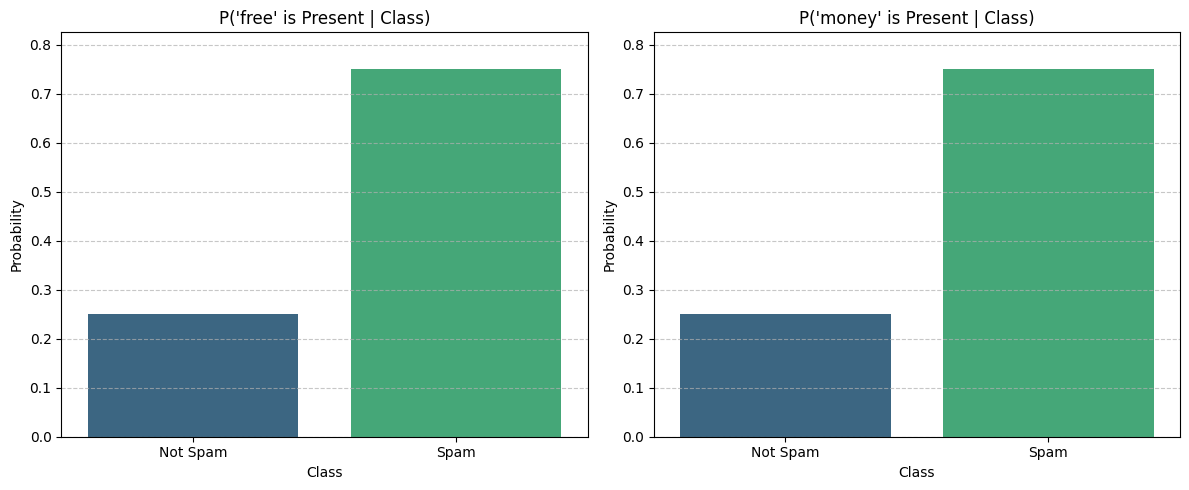

In [16]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Training Data ---
# Corpus is the same, but CountVectorizer will be configured for binary features
corpus = [
    'free money free',
    'free money',
    'hello dear',
    'hello dear'
]
labels = ['Spam', 'Spam', 'Not Spam', 'Not Spam']

df_emails = pd.DataFrame({'text': corpus, 'label': labels})

# --- 2. Feature Extraction: Convert text to binary presence vectors ---
# Use CountVectorizer with binary=True
vectorizer = CountVectorizer(lowercase=True, binary=True)
X = vectorizer.fit_transform(df_emails['text'])
y = df_emails['label']

# Display the vocabulary and the binary feature matrix
print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nBinary Feature Matrix (Presence/Absence):")
display(pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=df_emails['text']))

# --- 3. Train Bernoulli Naive Bayes Model ---
# alpha=1.0 for Laplace smoothing
bnb_model = BernoulliNB(alpha=1.0)
bnb_model.fit(X, y)

# --- 4. Prediction Phase: Classify new email ---
new_email_text = ['free money']
X_new = vectorizer.transform(new_email_text)

# Predict the class
predicted_class = bnb_model.predict(X_new)
print(f"\nPredicted class for '{new_email_text[0]}': {predicted_class[0]}")

# Get probability estimates for each class
probabilities = bnb_model.predict_proba(X_new)
class_labels = bnb_model.classes_

print("\nProbability estimates for the new email:")
for i, label in enumerate(class_labels):
    print(f"P({label} | 'free money') = {probabilities[0, i]:.7f}")

# --- 5. Visualization of Word Presence Probabilities per Class ---
# These are P(feature_present | class) with smoothing

# bnb_model.feature_log_prob_ provides log P(feature_present | class) and log P(feature_absent | class)
# We specifically want P(feature_present | class)
# The structure is [[log P(x_i=0 | C0), log P(x_i=0 | C1), ...], [log P(x_i=1 | C0), log P(x_i=1 | C1), ...]] for each feature
# For BernoulliNB, feature_log_prob_ gives P(feature_value | class) where feature_value is 0 or 1.
# The relevant attribute for P(feature_present=1 | class) is usually stored internally or derived.

# Let's manually reconstruct P(word_present | class) for clarity from counts or use feature_log_prob_ directly.
# BernoulliNB's feature_log_prob_ is structured differently than MultinomialNB's.
# It has two rows per class (for feature=0 and feature=1). No, it's actually one entry per class for presence, and 1-p for absence

# The p(feature=1|class) values are directly available as exp(bnb_model.feature_log_prob_[class_idx, feature_idx])
# This attribute gives log P(feature_value | class) for a feature value of 1.

# Let's derive P(word_present | class) and P(word_absent | class) from model's internal counts
# or directly from feature_log_prob_ attribute if it's interpretable as P(x_i=1 | Ck)

# Based on sklearn documentation: feature_log_prob_[class_idx, feature_idx] = log(P(feature_idx=1 | class_idx)) if feature is present.
# So, to get P(word_present | class):
word_present_probs = np.exp(bnb_model.feature_log_prob_)

word_probs_df = pd.DataFrame(
    word_present_probs,
    columns=vectorizer.get_feature_names_out(),
    index=bnb_model.classes_
)

print("\nWord Presence Probabilities P(word_present | class) with Laplace smoothing:")
display(word_probs_df)

# Plotting example: 'free' and 'money' presence likelihoods
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Likelihood of 'free' presence
sns.barplot(x=word_probs_df.index, y=word_probs_df['free'], ax=axes[0], palette='viridis', hue=word_probs_df.index, legend=False)
axes[0].set_title("P('free' is Present | Class)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, max(word_probs_df['free'].max(), word_probs_df['money'].max()) * 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Likelihood of 'money' presence
sns.barplot(x=word_probs_df.index, y=word_probs_df['money'], ax=axes[1], palette='viridis', hue=word_probs_df.index, legend=False)
axes[1].set_title("P('money' is Present | Class)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, max(word_probs_df['free'].max(), word_probs_df['money'].max()) * 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 10.6 Pros & Cons of Bernoulli Naive Bayes

**Pros:**

*   **Suitable for Binary Data:** Specifically designed for features that represent presence or absence, making it a good choice when features are naturally binary or can be binarized.
*   **Effective for Short Texts:** For tasks where the occurrence of a single keyword is highly indicative, and frequency doesn't add much information (e.g., in very short tweets, SMS messages, or specific keyword spotting), BNB can be very effective.
*   **Handles Feature Absence:** Unlike some models that might ignore absent features, BNB explicitly models the probability of a feature *not* being present, which can be crucial information.
*   **Computational Efficiency:** Like other Naive Bayes variants, it is computationally fast to train and predict, making it scalable for large datasets.
*   **Simplicity:** Easy to understand and implement.

**Cons:**

*   **Strong Independence Assumption:** Shares the same 'naive' assumption as other Naive Bayes variants, which can lead to suboptimal performance if features are highly dependent.
*   **Ignores Frequency Information:** By only considering presence/absence, it discards valuable information about the frequency of terms, which Multinomial Naive Bayes uses effectively. This can be a disadvantage in many text classification tasks where word counts are important.
*   **Zero-Frequency Problem:** Similar to MNB, it requires smoothing (like Laplace smoothing) to handle cases where a feature present in the test set was never seen in a particular class during training.
*   **Not Suitable for Continuous Data:** Cannot directly handle continuous numerical features without prior binarization, which might lead to loss of information.

### 10.7 Comparison with other Naive Bayes variants and Relevance

Bernoulli Naive Bayes carves out its own niche within the Naive Bayes family by focusing on the binary nature of features.

*   **Vs. Gaussian Naive Bayes (GNB):**
    *   **BNB:** For binary features (presence/absence). Assumes features are from a Bernoulli distribution.
    *   **GNB:** For continuous features. Assumes features are from a Gaussian distribution.
    *   **Key Difference:** The fundamental data type they are designed to handle and the statistical distribution used to model likelihoods.

*   **Vs. Multinomial Naive Bayes (MNB):**
    *   **BNB:** Considers only the *presence or absence* of features. Ignores frequency. Best when occurrence is key.
    *   **MNB:** Considers the *count* of how many times features appear. Best when frequency is informative (e.g., longer text documents).
    *   **Key Difference:** How feature information is interpreted. MNB models counts, while BNB models binary outcomes. For text classification, MNB is generally preferred for longer documents, whereas BNB might be chosen for very short, keyword-driven texts or when explicitly converting to a binary feature representation (e.g., for certain NLP tasks where TF-IDF is binarized).

**Relevance to Naive Bayes:**

Bernoulli Naive Bayes reinforces the adaptability of the Naive Bayes framework. By changing the underlying probability distribution assumption ($P(x_i | C_k)$), the algorithm can be tailored to different types of data (continuous, count, binary). BNB is a valuable tool for specific types of classification problems, especially those involving binary features or situations where feature presence/absence is more relevant than frequency. It highlights that selecting the right Naive Bayes variant depends critically on the nature of your features.

## 11. Laplace Smoothing

### 11.1 Why we need Laplace Smoothing

In Naive Bayes algorithms (especially Multinomial and Bernoulli), we estimate probabilities like $P(\text{feature} | \text{class})$ by counting frequencies from the training data. A critical problem arises when a feature (e.g., a specific word) appears in the test set but was *never seen* in the training data for a particular class.

Consider our spam/not-spam example. If the word "viagra" is present in a test email, but it *never* appeared in any of the 'Spam' training emails, then its estimated likelihood $P(\text{viagra} | \text{Spam})$ would be 0. Since Naive Bayes multiplies these likelihoods, a single zero likelihood will cause the entire posterior probability for that class ($P(\text{Spam} | \text{email with 'viagra'})$) to become zero, regardless of other strong indicators. This is called the **zero-frequency problem**.

This is problematic because it means the model is overly confident that an unseen feature implies absolute impossibility for a class, which is often an incorrect assumption. A new, legitimate email might contain a rare word not in the 'Not Spam' training set, and without smoothing, the model might incorrectly classify it.

**Laplace Smoothing (or additive smoothing)** addresses this by ensuring that all words/features have a non-zero probability, thus preventing the entire probability product from becoming zero and allowing the model to make more robust predictions.

### 11.2 Definition & Intuition

**Definition:** Laplace smoothing is a technique used to overcome the zero-frequency problem in Naive Bayes. It works by adding a small constant value (typically 1, hence "add-1 smoothing") to the count of every feature for every class, and adjusting the denominator accordingly. This ensures that even features not observed in the training data for a particular class still get a non-zero probability.

**Intuition:** Imagine you're counting colored balls in two jars, representing 'Class A' and 'Class B'.

*   **Jar A (Class A):** Has 10 red balls, 5 blue balls. (Total 15 balls)
*   **Jar B (Class B):** Has 0 red balls, 8 blue balls. (Total 8 balls)

If you draw a red ball, and you want to decide which jar it came from: $P(\text{Red} | \text{Jar B})$ is 0. This seems too strong. What if you just haven't seen enough balls from Jar B yet?

With Laplace Smoothing (add-1): You pretend you've already seen one of each possible ball color in every jar. If there are, say, 3 possible colors (red, blue, green):

*   **Jar A (Class A):** Now has (10+1) red, (5+1) blue, (0+1) green. Total balls: 15 + 3 = 18.
    *   $P(\text{Red} | \text{Jar A}) = 11/18$
*   **Jar B (Class B):** Now has (0+1) red, (8+1) blue, (0+1) green. Total balls: 8 + 3 = 11.
    *   $P(\text{Red} | \text{Jar B}) = 1/11$

Now, $P(\text{Red} | \text{Jar B})$ is no longer zero. It's a small, non-zero probability, which allows the algorithm to still consider Jar B as a possibility, rather than completely ruling it out based on limited training data. This makes the probability estimates more robust and avoids numerical instability.

### 11.3 Math Behind & Formula

Laplace smoothing modifies the calculation of conditional probabilities (likelihoods) $P(x_i | C_k)$ in both Multinomial and Bernoulli Naive Bayes.

**1. For Multinomial Naive Bayes (Count Data):**

The original formula for $P(x_i | C_k)$ is:
$$P(x_i | C_k) = \frac{\text{count of word } i \text{ in class } C_k}{\text{total words in class } C_k}$$

With Laplace Smoothing (additive smoothing, often $\alpha=1$):
$$P(x_i | C_k) = \frac{(\text{count of word } i \text{ in class } C_k) + \alpha}{(\text{total words in class } C_k) + \alpha \cdot V}$$
Where:
*   $\alpha$: The smoothing parameter (usually 1 for Laplace, or other values for Lidstone smoothing).
*   $V$: The size of the vocabulary (total number of unique features/words across all classes).

**2. For Bernoulli Naive Bayes (Binary Data):**

The original formula for $P(x_i=1 | C_k)$ (probability of feature $i$ being present in class $C_k$) is:
$$P(x_i=1 | C_k) = \frac{\text{count of documents in } C_k \text{ where feature } i \text{ is present}}{\text{total count of documents in } C_k}$$

With Laplace Smoothing (additive smoothing, often $\alpha=1$):
$$P(x_i=1 | C_k) = \frac{(\text{count of documents in } C_k \text{ where feature } i \text{ is present}) + \alpha}{(\text{total count of documents in } C_k) + 2\alpha}$$
Where:
*   $\alpha$: The smoothing parameter.
*   The $2\alpha$ in the denominator accounts for the two possible outcomes (presence or absence) of a Bernoulli trial, ensuring that the probabilities for presence and absence sum correctly after smoothing.

### 11.4 Numerical Example

Let's revisit our text classification example from Multinomial Naive Bayes, specifically focusing on how smoothing affects the likelihoods. (We used $\alpha=1$ implicitly in the previous example, but let's highlight its effect).

**Training Data (Word Counts):**

| Document | Class      | 'free' | 'money' | 'hello' | 'dear' | 'bonus' |
| :------- | :--------- | :----- | :------ | :------ | :----- | :------ |
| Doc 1    | Spam       | 2      | 1       | 0       | 0      | 0       |
| Doc 2    | Spam       | 1      | 1       | 0       | 0      | 0       |
| Doc 3    | Not Spam   | 0      | 0       | 1       | 1      | 0       |
| Doc 4    | Not Spam   | 0      | 0       | 1       | 1      | 0       |

**New Word:** Let's assume our vocabulary now includes a new word: **'bonus'**.

**Vocabulary (V):** {'free', 'money', 'hello', 'dear', 'bonus'} (V = 5 words)

Let's calculate $P(\text{'bonus'} | \text{Spam})$ and $P(\text{'bonus'} | \text{Not Spam})$ with and without Laplace Smoothing ($\alpha=1$).

**Without Laplace Smoothing:**

*   **Total words in Spam class:** $2+1+0+0+0 = 3$
*   **Count of 'bonus' in Spam class:** 0
*   $P(\text{'bonus'} | \text{Spam}) = 0/3 = 0$

*   **Total words in Not Spam class:** $0+0+1+1+0 = 2$
*   **Count of 'bonus' in Not Spam class:** 0
*   $P(\text{'bonus'} | \text{Not Spam}) = 0/2 = 0$

As you can see, without smoothing, if 'bonus' appears in a new email, both posterior probabilities ($P(\text{Spam}|...)$ and $P(\text{Not Spam}|...)$) would become zero because of this single word, rendering the classification useless.

**With Laplace Smoothing ($\alpha = 1$ for Multinomial Naive Bayes):**

*   **Revised Total words in Spam class:** (Original Total words) + $\alpha \cdot V = 3 + 1 \cdot 5 = 8$
*   **Revised Count of 'bonus' in Spam class:** (Original Count) + $\alpha = 0 + 1 = 1$
*   $P(\text{'bonus'} | \text{Spam}) = 1/8 = 0.125$

*   **Revised Total words in Not Spam class:** (Original Total words) + $\alpha \cdot V = 2 + 1 \cdot 5 = 7$
*   **Revised Count of 'bonus' in Not Spam class:** (Original Count) + $\alpha = 0 + 1 = 1$
*   $P(\text{'bonus'} | \text{Not Spam}) = 1/7 \approx 0.1428$

Now, with Laplace smoothing, even though 'bonus' was not seen in the training data, it has a non-zero probability for both classes. This prevents the entire posterior probability from vanishing to zero, allowing the model to make a meaningful classification based on other words in the email.

### 11.5 Python Code to Explain the Subtopic

Let's demonstrate the effect of Laplace smoothing in Python by comparing probabilities calculated with and without it, particularly for unseen words, using a simple Multinomial Naive Bayes setup.

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np

# --- 1. Training Data (with a potential unseen word) ---
corpus = [
    'free money free',
    'free money',
    'hello dear',
    'hello dear'
]
labels = ['Spam', 'Spam', 'Not Spam', 'Not Spam']

df_emails = pd.DataFrame({'text': corpus, 'label': labels})

# The word 'bonus' is NOT in the training corpus
unseen_word = 'bonus'

# --- 2. Feature Extraction ---
vectorizer = CountVectorizer(lowercase=True)
X_train = vectorizer.fit_transform(df_emails['text'])
y_train = df_emails['label']

vocabulary = vectorizer.get_feature_names_out()
V = len(vocabulary)

print(f"Vocabulary: {vocabulary} (Size V={V})")
print("\nTraining Feature Matrix (Word Counts):")
display(pd.DataFrame(X_train.toarray(), columns=vocabulary, index=df_emails['text']))

# --- 3. Manually calculate likelihoods without smoothing (demonstrate zero-frequency) ---
print("\n--- Likelihoods WITHOUT Laplace Smoothing (alpha=0) ---")

# Get the word counts for each feature for 'Spam' and 'Not Spam' classes
# Use .sum(axis=0) to sum by column (for each word) and .A1 to flatten to a 1D array
spam_feature_counts_orig = X_train[np.array(y_train == 'Spam')].sum(axis=0).A1
not_spam_feature_counts_orig = X_train[np.array(y_train == 'Not Spam')].sum(axis=0).A1

temp_vocab = vocabulary # Start with original vocabulary

# Extend word counts for each class with 0 for the unseen word, if applicable
if unseen_word not in vocabulary:
    temp_vocab = np.append(vocabulary, unseen_word) # Extended vocabulary

    # Explicitly create 2D array for the data
    data_for_df = np.array([
        np.append(spam_feature_counts_orig, 0),
        np.append(not_spam_feature_counts_orig, 0)
    ])

    # Create the DataFrame with classes as index and extended vocabulary as columns
    total_words_per_class_df = pd.DataFrame(
        data_for_df,                            # Explicit 2D numpy array
        index=['Spam', 'Not Spam'],             # Row labels
        columns=temp_vocab                      # Column labels
    )
else:
    # If unseen_word is already in vocabulary, use original counts and vocabulary
    total_words_per_class_df = pd.DataFrame(
        [spam_feature_counts_orig, not_spam_feature_counts_orig],
        index=['Spam', 'Not Spam'],
        columns=vocabulary
    )

# Now calculate likelihoods
likelihood_no_smoothing = pd.DataFrame(index=['Spam', 'Not Spam'], columns=temp_vocab)

for cls in ['Spam', 'Not Spam']:
    # Sum of all word counts in this class from the original training data (scalar)
    sum_words_in_class = X_train[np.array(y_train == cls)].sum() # This returns a scalar (e.g., 5 for Spam, 4 for Not Spam)

    for word in temp_vocab:
        # Get count from the prepared DataFrame
        word_count_in_class = total_words_per_class_df.loc[cls, word]

        # Handle division by zero if sum_words_in_class is 0 (unlikely with training data here)
        if sum_words_in_class == 0:
            likelihood_no_smoothing.loc[cls, word] = 0.0
        else:
            likelihood_no_smoothing.loc[cls, word] = word_count_in_class / sum_words_in_class

display(likelihood_no_smoothing)

# --- 4. Train Multinomial Naive Bayes Model with Laplace Smoothing (alpha=1.0) ---
print("\n--- Likelihoods WITH Laplace Smoothing (alpha=1) ---")

mnb_model = MultinomialNB(alpha=1.0) # alpha=1.0 for Laplace smoothing
mnb_model.fit(X_train, y_train)

# To get the likelihoods P(word | class) with smoothing, we use feature_log_prob_
# and convert from log probabilities to probabilities.
feature_log_prob = mnb_model.feature_log_prob_
word_probabilities_per_class = np.exp(feature_log_prob)

word_probs_df_smoothed = pd.DataFrame(
    word_probabilities_per_class,
    columns=vocabulary,
    index=mnb_model.classes_
)

# Now, let's also calculate for the unseen word 'bonus'
# We need to manually calculate it based on the formula:
# P('bonus' | Ck) = (count('bonus' in Ck) + alpha) / (total words in Ck + alpha * V)
# For 'bonus', original count in all classes is 0

alpha = mnb_model.alpha # Get alpha used by the model

# Calculate smoothed likelihood for 'bonus' for each class
# Note: This is an estimation for a word not seen by CountVectorizer.
# In a real scenario, unseen_word would be handled by adding to vocab or pre-processing.
# Here, we show the mathematical impact of smoothing.

smoothed_likelihoods_unseen = {}
for i, cls in enumerate(mnb_model.classes_):
    # original_total_words_in_class needs to be the sum of all word counts for that class
    original_total_words_in_class = X_train[np.array(y_train == cls)].sum() # This should be scalar, already confirmed
    smoothed_denominator = original_total_words_in_class + alpha * V
    smoothed_likelihoods_unseen[cls] = alpha / smoothed_denominator

# Add 'bonus' likelihoods to the smoothed DataFrame for comparison
word_probs_df_smoothed[unseen_word] = pd.Series(smoothed_likelihoods_unseen)

display(word_probs_df_smoothed)

print("\nObserve how for the word 'bonus' (which was not in training data), likelihoods are 0 without smoothing, but non-zero with Laplace smoothing.")

Vocabulary: ['dear' 'free' 'hello' 'money'] (Size V=4)

Training Feature Matrix (Word Counts):


,dear,free,hello,money
text,,,,
free money free,0,2,0,1
free money,0,1,0,1
hello dear,1,0,1,0
hello dear,1,0,1,0



--- Likelihoods WITHOUT Laplace Smoothing (alpha=0) ---


,dear,free,hello,money,bonus
Spam,0.0,0.6,0.0,0.4,0.0
Not Spam,0.5,0.0,0.5,0.0,0.0



--- Likelihoods WITH Laplace Smoothing (alpha=1) ---


,dear,free,hello,money,bonus
Not Spam,0.375000,0.125000,0.375000,0.125000,0.125000
Spam,0.111111,0.444444,0.111111,0.333333,0.111111



Observe how for the word 'bonus' (which was not in training data), likelihoods are 0 without smoothing, but non-zero with Laplace smoothing.


### 11.6 Pros & Cons of Laplace Smoothing

**Pros:**

*   **Solves Zero-Frequency Problem:** This is its primary and most significant advantage. It ensures that no probability estimate is exactly zero, preventing entire posterior probabilities from becoming zero due to a single unseen feature.
*   **Increases Robustness:** Makes Naive Bayes models more robust to sparse data and features that might not be present in all classes in the training set but could appear in new data.
*   **Simple to Implement:** It's a straightforward mathematical adjustment to the probability estimation formulas.
*   **Avoids Numerical Instability:** Prevents issues that can arise in log-probability calculations (log(0) is undefined).

**Cons:**

*   **Introduces Bias:** By adding pseudo-counts, Laplace smoothing can bias the probability estimates, especially if the dataset is small or if certain features are genuinely very rare and should have a low probability. It assumes that every unseen event has occurred $\alpha$ times.
*   **Can Over-smooth:** If $\alpha$ is too large, it can over-smooth the probabilities, making them too uniform and reducing the discriminative power of features.
*   **Assumption of Uniform Distribution:** Add-1 smoothing implicitly assumes that all unseen events are equally likely, which may not be true.
*   **Doesn't Address Feature Selection:** While it handles unseen *values* of existing features, it doesn't help with features that are entirely irrelevant or should be excluded from the model.

### 11.7 Comparison with other smoothing techniques and Relevance

Laplace smoothing is one of several techniques for smoothing probability estimates, particularly in language modeling and text classification. Its relevance to Naive Bayes is fundamental.

*   **Comparison to other smoothing techniques:**
    *   **Lidstone Smoothing (Add-$\alpha$ Smoothing):** Laplace smoothing is a specific case of Lidstone smoothing where $\alpha = 1$. Lidstone smoothing allows $\alpha$ to be any non-negative value (often between 0 and 1). A smaller $\alpha$ introduces less bias but is still effective in preventing zero probabilities. Sklearn's `MultinomialNB` and `BernoulliNB` use `alpha` as the parameter for Lidstone smoothing.
    *   **Witten-Bell Smoothing, Good-Turing Smoothing, Kneser-Ney Smoothing:** These are more advanced and complex smoothing techniques, often used in natural language processing (NLP) for n-gram language models. They typically try to provide more sophisticated estimates for unseen events based on the frequency of observed events, often outperforming simple additive smoothing in large-scale NLP tasks. However, their complexity is usually not warranted for the basic Naive Bayes implementations in `sklearn` or similar general-purpose libraries.

*   **Relevance to Naive Bayes:**
    Laplace smoothing (or its generalized form, Lidstone smoothing) is an integral part of practical Naive Bayes implementations. Without it, Naive Bayes would be highly prone to the zero-frequency problem, especially when dealing with sparse data like text, where a large number of possible words might only appear a few times or not at all in specific classes within the training data. It ensures that the model can still assign a meaningful (though small) probability to features it hasn't seen before, making classifications more robust and preventing the entire model from breaking down. It's a simple yet highly effective technique that contributes significantly to the real-world utility of Naive Bayes classifiers.

## 12. Log Probability

### 12.1 Why we need Log Probability

In Naive Bayes, we calculate the posterior probability by multiplying many individual probabilities:

$$P(C_k | X) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)$$

Each of these individual probabilities, $P(C_k)$ and $P(x_i | C_k)$, are typically small numbers between 0 and 1. When you multiply many such small numbers together, especially in datasets with a large number of features (like text classification with thousands of words), the resulting product can become extremely small. This leads to two major problems:

1.  **Underflow:** Standard floating-point representations in computers have a limited range. When numbers become too small, they can 'underflow' to zero. If the product of probabilities underflows to zero for all classes, it becomes impossible to compare them and make a classification decision.

2.  **Computational Instability:** Even before underflow, working with extremely small numbers can lead to precision issues and numerical instability during calculations.

**Log Probability** (or log-likelihood) solves this problem. Instead of multiplying small probabilities, we convert them to their logarithms and then sum them. The logarithm of a small number (between 0 and 1) is a large negative number. Summing large negative numbers is numerically much more stable and avoids underflow issues. Moreover, maximizing a probability is equivalent to maximizing its logarithm, so the classification decision remains the same.

### 12.2 Definition & Intuition

**Definition:** Log probability is simply the logarithm of a probability. Instead of working directly with $P(A)$, we work with $\log(P(A))$. In the context of Naive Bayes, instead of multiplying individual probabilities to get the overall probability, we take the logarithm of each probability and then sum them.

**Intuition:**

1.  **Product to Sum:** The fundamental property of logarithms is that $\log(a \cdot b) = \log(a) + \log(b)$. This is incredibly useful. When we have a product of many small probabilities, like $\prod P(x_i | C_k)$, taking the logarithm transforms this product into a sum: $\sum \log(P(x_i | C_k))$. Summing numbers is much more numerically stable than multiplying many small floating-point numbers.

2.  **Avoiding Underflow:** Probabilities are between 0 and 1. The logarithm of a number between 0 and 1 is a negative number. For example, $\log(0.001) = -3$, $\log(0.000001) = -6$. As probabilities get smaller, their logarithms become larger negative numbers. This avoids floating-point underflow where very small numbers get rounded down to zero.

3.  **Monotonic Transformation:** The logarithm function is a monotonically increasing function. This means that if $P(A) > P(B)$, then $\log(P(A)) > \log(P(B))$. Therefore, maximizing the probability $P(C_k | X)$ is equivalent to maximizing its logarithm $\log(P(C_k | X))$. The classification decision remains the same, but the calculations are more robust.

### 12.3 Math Behind & Formula

In Naive Bayes, our goal is to find the class $C_k$ that maximizes the posterior probability $P(C_k | X)$. According to Bayes' Theorem and the naive independence assumption, this is proportional to:

$$P(C_k | X) \propto P(C_k) \cdot P(X | C_k)$$
$$P(C_k | X) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)$$

To avoid numerical underflow and improve computational stability, we take the logarithm of this expression. Since $\log$ is a monotonically increasing function, maximizing the probability is equivalent to maximizing its logarithm:

$$\log(P(C_k | X)) \propto \log(P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k))$$

Using the logarithm properties $(\log(a \cdot b) = \log(a) + \log(b))$ and $(\log(\prod a_i) = \sum \log(a_i))$, we transform the product into a sum:

$$\log(P(C_k | X)) \propto \log(P(C_k)) + \sum_{i=1}^{n} \log(P(x_i | C_k))$$

This is the core mathematical formulation of log probabilities in Naive Bayes. Instead of calculating the raw probabilities and multiplying them, we calculate the log of the prior and the log of each feature's likelihood, and then sum these log values. The class with the highest sum of log probabilities is the predicted class.

**Note:** When using log probabilities, any probability that is 0 would lead to $\log(0)$, which is undefined (approaches $-\infty$). This is another crucial reason why **Laplace Smoothing** is essential before taking logarithms, as it ensures all probabilities are non-zero.

### 12.4 Numerical Example

Let's use a very simple scenario to demonstrate the use of log probabilities. Imagine we are classifying a document as 'Class A' or 'Class B' based on the presence of two words: 'word1' and 'word2'.

**Given Probabilities (already smoothed, non-zero):**

*   **Prior Probabilities:**
    *   $P(\text{Class A}) = 0.5$
    *   $P(\text{Class B}) = 0.5$

*   **Likelihoods:**
    *   $P(\text{word1} | \text{Class A}) = 0.001$ (a very rare word for Class A)
    *   $P(\text{word2} | \text{Class A}) = 0.005$
    *   $P(\text{word1} | \text{Class B}) = 0.0001$ (even rarer for Class B)
    *   $P(\text{word2} | \text{Class B}) = 0.01$

**Task:** Classify a new document containing 'word1' and 'word2'.

**1. Calculate Normal Probabilities (Product):**

*   **For Class A:**
    $P(\text{Class A | words}) \propto P(\text{Class A}) \cdot P(\text{word1} | \text{Class A}) \cdot P(\text{word2} | \text{Class A})$
    $= 0.5 \cdot 0.001 \cdot 0.005 = 0.0000025$

*   **For Class B:**
    $P(\text{Class B | words}) \propto P(\text{Class B}) \cdot P(\text{word1} | \text{Class B}) \cdot P(\text{word2} | \text{Class B})$
    $= 0.5 \cdot 0.0001 \cdot 0.01 = 0.0000005$

Comparing $0.0000025$ and $0.0000005$, Class A is more likely.

**Problems with this approach:** These numbers are already very small. Imagine if we had 100 or 1000 features. The product would quickly underflow to 0, making classification impossible.

**2. Calculate Log Probabilities (Sum):**

First, convert all individual probabilities to their natural logarithms ($\ln$):

*   $\ln(P(\text{Class A})) = \ln(0.5) \approx -0.693$
*   $\ln(P(\text{Class B})) = \ln(0.5) \approx -0.693$

*   $\ln(P(\text{word1} | \text{Class A})) = \ln(0.001) \approx -6.908$
*   $\ln(P(\text{word2} | \text{Class A})) = \ln(0.005) \approx -5.298$

*   $\ln(P(\text{word1} | \text{Class B})) = \ln(0.0001) \approx -9.210$
*   $\ln(P(\text{word2} | \text{Class B})) = \ln(0.01) \approx -4.605$

Now, sum the log probabilities:

*   **For Class A:**
    $\log(P(\text{Class A | words})) \propto \ln(P(\text{Class A})) + \ln(P(\text{word1} | \text{Class A})) + \ln(P(\text{word2} | \text{Class A}))$
    $\approx -0.693 + (-6.908) + (-5.298) = -12.899$

*   **For Class B:**
    $\log(P(\text{Class B | words})) \propto \ln(P(\text{Class B})) + \ln(P(\text{word1} | \text{Class B})) + \ln(P(\text{word2} | \text{Class B}))$
    $\approx -0.693 + (-9.210) + (-4.605) = -14.508$

Comparing the log probabilities: **$-12.899 > -14.508$**.

Since $-12.899$ is a larger (less negative) number than $-14.508$, **Class A** is still determined to be more likely. The classification decision remains the same, but the calculations are numerically stable and avoid underflow, even with many small probabilities.

### 12.5 Python Code to Explain the Subtopic

Let's implement the numerical example using Python to illustrate the stability gained by using log probabilities. We will use `numpy.log` for natural logarithm.

--- Normal Probabilities (Product) ---
P(Class A | words) proportional to: 0.0000025
P(Class B | words) proportional to: 0.0000005
Predicted Class (Normal Probabilities): Class A

--- Log Probabilities (Sum) ---
Log P(Class A | words) proportional to: -12.899
Log P(Class B | words) proportional to: -14.509
Predicted Class (Log Probabilities): Class A


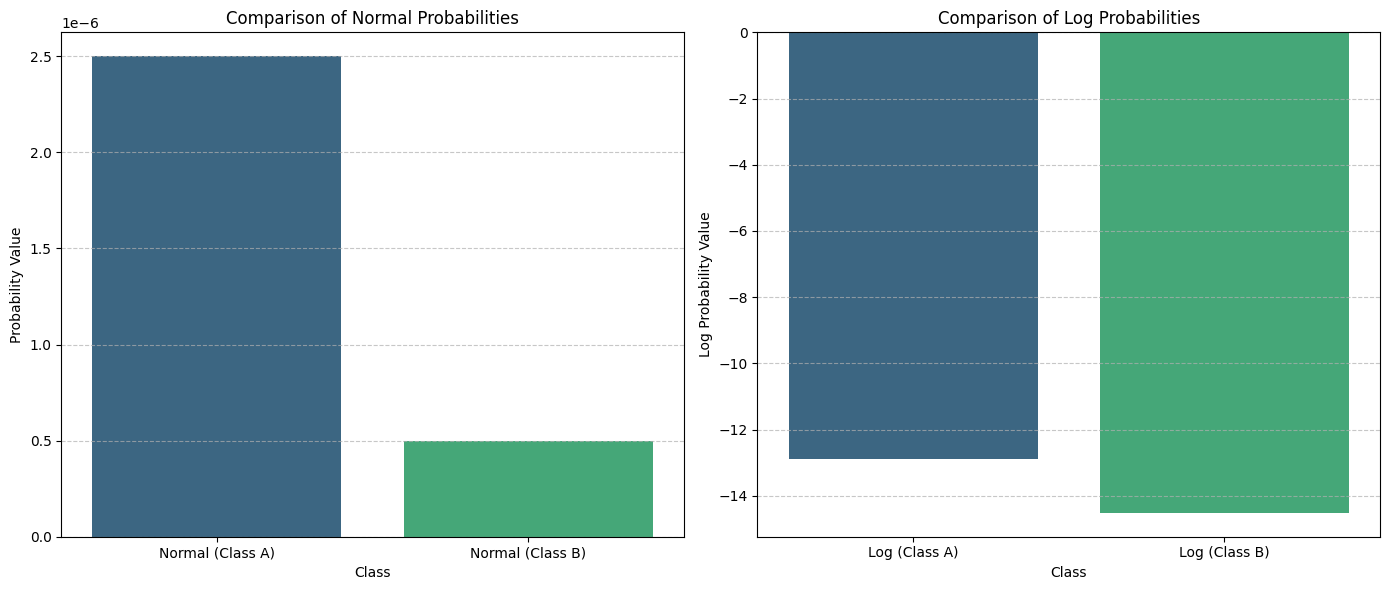

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Given Probabilities
p_class_a = 0.5
p_class_b = 0.5

p_word1_given_a = 0.001
p_word2_given_a = 0.005

p_word1_given_b = 0.0001
p_word2_given_b = 0.01

# --- 1. Calculate Normal Probabilities (Product) ---

# For Class A
prob_a_normal = p_class_a * p_word1_given_a * p_word2_given_a

# For Class B
prob_b_normal = p_class_b * p_word1_given_b * p_word2_given_b

print("--- Normal Probabilities (Product) ---")
print(f"P(Class A | words) proportional to: {prob_a_normal:.7f}")
print(f"P(Class B | words) proportional to: {prob_b_normal:.7f}")

if prob_a_normal > prob_b_normal:
    print("Predicted Class (Normal Probabilities): Class A")
elif prob_b_normal > prob_a_normal:
    print("Predicted Class (Normal Probabilities): Class B")
else:
    print("Predicted Class (Normal Probabilities): Tie")

# --- 2. Calculate Log Probabilities (Sum) ---

# Convert to log probabilities
log_p_class_a = np.log(p_class_a)
log_p_class_b = np.log(p_class_b)

log_p_word1_given_a = np.log(p_word1_given_a)
log_p_word2_given_a = np.log(p_word2_given_a)

log_p_word1_given_b = np.log(p_word1_given_b)
log_p_word2_given_b = np.log(p_word2_given_b)

# For Class A
log_prob_a = log_p_class_a + log_p_word1_given_a + log_p_word2_given_a

# For Class B
log_prob_b = log_p_class_b + log_p_word1_given_b + log_p_word2_given_b

print("\n--- Log Probabilities (Sum) ---")
print(f"Log P(Class A | words) proportional to: {log_prob_a:.3f}")
print(f"Log P(Class B | words) proportional to: {log_prob_b:.3f}")

if log_prob_a > log_prob_b:
    print("Predicted Class (Log Probabilities): Class A")
elif log_prob_b > log_prob_a:
    print("Predicted Class (Log Probabilities): Class B")
else:
    print("Predicted Class (Log Probabilities): Tie")

# --- Visualization ---
probabilities_data = {
    'Method': ['Normal (Class A)', 'Normal (Class B)', 'Log (Class A)', 'Log (Class B)'],
    'Value': [prob_a_normal, prob_b_normal, log_prob_a, log_prob_b]
}
df_probs = pd.DataFrame(probabilities_data)

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Normal Probabilities
sns.barplot(x=df_probs['Method'][:2], y=df_probs['Value'][:2], ax=axes[0], palette='viridis', hue=df_probs['Method'][:2], legend=False)
axes[0].set_title('Comparison of Normal Probabilities')
axes[0].set_ylabel('Probability Value')
axes[0].set_xlabel('Class')
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(-3,3)) # Use scientific notation for small numbers
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Log Probabilities
sns.barplot(x=df_probs['Method'][2:], y=df_probs['Value'][2:], ax=axes[1], palette='viridis', hue=df_probs['Method'][2:], legend=False)
axes[1].set_title('Comparison of Log Probabilities')
axes[1].set_ylabel('Log Probability Value')
axes[1].set_xlabel('Class')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 12.6 Pros & Cons

**Pros of using Log Probabilities in Naive Bayes:**

*   **Numerical Stability:** This is the primary advantage. It avoids floating-point underflow issues that arise from multiplying many small probabilities, ensuring that calculations remain accurate even with large numbers of features.
*   **Computational Efficiency:** Summing logarithms is generally faster than multiplying many floating-point numbers, especially if custom arbitrary-precision arithmetic were needed to avoid underflow in the non-log domain.
*   **Preserves Decision:** Because the logarithm is a monotonic function, maximizing the sum of log probabilities is equivalent to maximizing the product of normal probabilities. The final classification decision remains unchanged.
*   **Avoids `log(0)` with Smoothing:** When combined with Laplace smoothing, which ensures all probabilities are non-zero, log probabilities completely circumvent issues of `log(0)` (which is undefined or $-\infty$), leading to a robust system.

**Cons of using Log Probabilities:**

*   **Interpretability:** The raw sums of log probabilities are not as intuitively interpretable as direct probabilities. While they provide the correct ranking for classification, converting them back to probabilities can sometimes be necessary for specific analyses, requiring an exponential operation.
*   **Dependency on Base:** The specific numerical value of the log probability sum depends on the base of the logarithm used (e.g., natural log `ln` vs. base 10 `log10`). However, the *ranking* of classes remains invariant to the base, which is what matters for classification.

### 12.7 Comparison with other techniques/Relevance

Log probability is not a machine learning algorithm itself, but a crucial mathematical technique applied within many probabilistic models, including Naive Bayes. Its relevance extends beyond Naive Bayes to several other areas:

*   **General Probabilistic Models:** Any model that involves multiplying many probabilities (e.g., Hidden Markov Models, Bayesian Networks, graphical models) often uses log probabilities to maintain numerical stability.

*   **Logistic Regression and other GLMs:** In logistic regression, the linear combination of features is passed through a sigmoid function to produce probabilities. When fitting these models, the objective function (e.g., cross-entropy loss) involves summing log probabilities. This makes optimization more stable.

*   **Maximum Likelihood Estimation (MLE):** When estimating parameters of a statistical model using MLE, we often maximize the log-likelihood function rather than the likelihood function itself. This converts a product of likelihoods into a sum of log-likelihoods, simplifying differentiation and optimization.

*   **Information Theory:** Concepts like entropy and cross-entropy, which are fundamental in evaluating machine learning models (especially classification models), are defined using logarithms of probabilities.

*   **Decision Trees/Random Forests:** These models typically don't directly work with probabilities in the same multiplicative way as Naive Bayes for classification, so the log probability technique isn't directly applied to their internal decision-making process. However, their evaluation metrics might involve log probabilities.

**Relevance to Naive Bayes:**

For Naive Bayes, log probabilities are not merely an optimization; they are often a **necessity** for practical implementation. Without them, the algorithm would frequently fail on real-world datasets due to underflow, especially in text classification where the number of features (words) can be enormous, and individual word probabilities within a class are very small. The combination of Laplace smoothing (to avoid `log(0)`) and log probabilities (to handle products of small numbers) transforms Naive Bayes from a theoretically sound but numerically fragile algorithm into a robust and widely applicable classifier.